In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("harinarayanan22/airquality")

print("Path to dataset files:", path)

c:\Users\icyez\OneDrive\Desktop\New folder\airquality\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\icyez\.cache\kagglehub\datasets\harinarayanan22\airquality\versions\1


In [2]:
import os
# List files in the dataset folder
dataset_path = r"C:\Users\icyez\.cache\kagglehub\datasets\harinarayanan22\airquality\versions\1"
for f in os.listdir(dataset_path):
    print(f)

AirQualityUCI.csv
AirQualityUCI.xlsx


In [3]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv(os.path.join(dataset_path, "AirQualityUCI.csv"), sep=";", decimal=",")
print("Shape:", df.shape)
df.head()

Shape: (9471, 17)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


# Task 1: Time-Series Preprocessing and Exploratory Analysis

## Problem Definition & Dataset Justification

**Dataset:** UCI Air Quality Dataset (AirQualityUCI)

**Problem:** Predict hourly Carbon Monoxide (CO) concentrations using sensor readings and meteorological data collected from a multisensor device deployed in an Italian city.

**Domain Relevance:** Air quality monitoring is critical for public health, urban planning, and environmental policy. CO is a toxic gas produced primarily by vehicle emissions and industrial processes. Accurate prediction of CO levels enables:
- Early warning systems for pollution episodes
- Validation of low-cost sensor networks against reference analyzers
- Understanding how meteorological conditions influence pollutant dispersion

**Justification:** This dataset is ideal for time-series analysis because:
1. It spans ~1 year of hourly readings (March 2004 – April 2005), providing rich temporal patterns
2. It contains both ground-truth reference measurements and metal-oxide sensor responses
3. It includes meteorological covariates (Temperature, Relative Humidity, Absolute Humidity)
4. It has realistic missing data patterns requiring careful preprocessing

**Target Variable:** `CO(GT)` — True hourly averaged CO concentration (mg/m³)

---

## A. Understanding the Dataset

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

# ──────────────────────────────────────────────────
# 1. Load and initial inspection
# ──────────────────────────────────────────────────
df_raw = pd.read_csv(
    os.path.join(dataset_path, "AirQualityUCI.csv"),
    sep=";", decimal=","
)

# Drop the two empty trailing columns
df_raw.drop(columns=["Unnamed: 15", "Unnamed: 16"], inplace=True, errors="ignore")

# Drop rows that are completely empty (trailing rows in the CSV)
df_raw.dropna(how="all", inplace=True)

print(f"Dataset shape after dropping empty cols/rows: {df_raw.shape}")
print(f"\nColumn names:\n{list(df_raw.columns)}")
print(f"\nData types:\n{df_raw.dtypes}")
df_raw.head(10)

Dataset shape after dropping empty cols/rows: (9357, 15)

Column names:
['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']

Data types:
Date                 str
Time                 str
CO(GT)           float64
PT08.S1(CO)      float64
NMHC(GT)         float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
dtype: object


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888
5,10/03/2004,23.00.00,1.2,1197.0,38.0,4.7,750.0,89.0,1337.0,96.0,1393.0,949.0,11.2,59.2,0.7848
6,11/03/2004,00.00.00,1.2,1185.0,31.0,3.6,690.0,62.0,1462.0,77.0,1333.0,733.0,11.3,56.8,0.7603
7,11/03/2004,01.00.00,1.0,1136.0,31.0,3.3,672.0,62.0,1453.0,76.0,1333.0,730.0,10.7,60.0,0.7702
8,11/03/2004,02.00.00,0.9,1094.0,24.0,2.3,609.0,45.0,1579.0,60.0,1276.0,620.0,10.7,59.7,0.7648
9,11/03/2004,03.00.00,0.6,1010.0,19.0,1.7,561.0,-200.0,1705.0,-200.0,1235.0,501.0,10.3,60.2,0.7517


In [4]:
# ──────────────────────────────────────────────────
# 2. Create proper DateTime index
# ──────────────────────────────────────────────────
df = df_raw.copy()

# Parse Date and Time into a single datetime column
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H.%M.%S')
df.set_index('DateTime', inplace=True)
df.drop(columns=['Date', 'Time'], inplace=True)
df.sort_index(inplace=True)

# ──────────────────────────────────────────────────
# 3. Time Range and Frequency
# ──────────────────────────────────────────────────
print("=" * 60)
print("TIME RANGE & FREQUENCY")
print("=" * 60)
print(f"Start:       {df.index.min()}")
print(f"End:         {df.index.max()}")
print(f"Duration:    {df.index.max() - df.index.min()}")
print(f"Total records: {len(df)}")

# Infer frequency
time_diffs = df.index.to_series().diff().dropna()
print(f"\nMost common time gap: {time_diffs.mode()[0]}")
print(f"Median time gap:      {time_diffs.median()}")
print(f"\nFrequency/Granularity: HOURLY (1-hour intervals)")
print(f"Expected records (hourly): {int((df.index.max() - df.index.min()).total_seconds() / 3600) + 1}")
print(f"Actual records:            {len(df)}")

TIME RANGE & FREQUENCY
Start:       2004-03-10 18:00:00
End:         2005-04-04 14:00:00
Duration:    389 days 20:00:00
Total records: 9357

Most common time gap: 0 days 01:00:00
Median time gap:      0 days 01:00:00

Frequency/Granularity: HOURLY (1-hour intervals)
Expected records (hourly): 9357
Actual records:            9357


MISSING VALUES ANALYSIS
               Missing Count (-200)  Missing %
NMHC(GT)                       8443      90.23
CO(GT)                         1683      17.99
NO2(GT)                        1642      17.55
NOx(GT)                        1639      17.52
PT08.S1(CO)                     366       3.91
PT08.S2(NMHC)                   366       3.91
C6H6(GT)                        366       3.91
PT08.S3(NOx)                    366       3.91
PT08.S4(NO2)                    366       3.91
PT08.S5(O3)                     366       3.91
T                               366       3.91
RH                              366       3.91
AH                              366       3.91


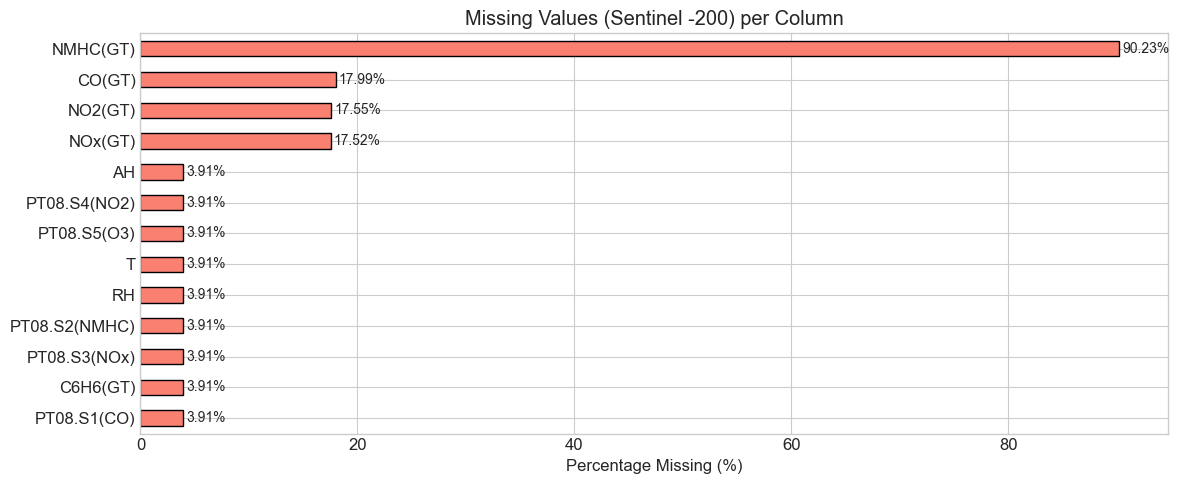

In [6]:
# ──────────────────────────────────────────────────
# 4. Missing Values Analysis
# ──────────────────────────────────────────────────
# In this dataset, -200 is the sentinel value for missing data
print("=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)

# Count -200 values per column (the dataset's missing indicator)
missing_sentinel = (df == -200).sum()
missing_pct = ((df == -200).sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count (-200)': missing_sentinel,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_df)

# Visualize missing values
fig, ax = plt.subplots(figsize=(12, 5))
missing_pct.sort_values(ascending=True).plot(kind='barh', ax=ax, color='salmon', edgecolor='black')
ax.set_xlabel('Percentage Missing (%)')
ax.set_title('Missing Values (Sentinel -200) per Column')
for i, v in enumerate(missing_pct.sort_values(ascending=True)):
    ax.text(v + 0.3, i, f'{v}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# ──────────────────────────────────────────────────
# 5. Handle Missing Values
# ──────────────────────────────────────────────────
"""
Missing Value Handling Strategy:
"""

df_clean = df.copy()

# Step 1: Drop NMHC(GT) — 90% missing
df_clean.drop(columns=['NMHC(GT)'], inplace=True)
print("Dropped NMHC(GT) column (90.23% missing — too sparse for reliable imputation)")

# Step 2: Replace -200 with NaN
df_clean.replace(-200, np.nan, inplace=True)

# Step 3: Count NaN after replacement
print(f"\nNaN counts after replacing -200:")
print(df_clean.isnull().sum())

# Step 4: Interpolate ground-truth columns (linear)
gt_cols = ['CO(GT)', 'NOx(GT)', 'NO2(GT)']
df_clean[gt_cols] = df_clean[gt_cols].interpolate(method='linear', limit_direction='both')

# Step 5: Forward-fill then back-fill sensor & meteorological columns
sensor_cols = ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'C6H6(GT)', 'PT08.S3(NOx)',
               'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
df_clean[sensor_cols] = df_clean[sensor_cols].ffill().bfill()

# Verify: no missing values remain
print(f"\nAfter imputation — remaining NaNs:")
print(df_clean.isnull().sum())
print(f"\nFinal dataset shape: {df_clean.shape}")

Dropped NMHC(GT) column (90.23% missing — too sparse for reliable imputation)

NaN counts after replacing -200:
CO(GT)           1683
PT08.S1(CO)       366
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64

After imputation — remaining NaNs:
CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

Final dataset shape: (9357, 12)


Missing Value Handling Strategy:
1. NMHC(GT) - 90.23% missing → DROP this column entirely (too sparse to impute reliably)
2. Replace -200 sentinel values with NaN
3. For sensor columns with ~3.91% missing → Forward-fill (ffill) then backward-fill (bfill)
   Reason: Sensor readings are temporally correlated; neighboring hourly readings are 
   the best proxy. Forward-fill preserves the most recent known state.
4. For ground-truth columns (CO, NOx, NO2) with ~17-18% missing → Linear interpolation
   Reason: These represent continuous physical measurements where linear interpolation 
   between known points produces physically plausible estimates.

STATISTICAL SUMMARY
                count      mean      std      min       25%       50%  \
CO(GT)         9357.0     2.131    1.432    0.100     1.100     1.800   
PT08.S1(CO)    9357.0  1102.730  219.588  647.000   938.000  1062.000   
C6H6(GT)       9357.0    10.190    7.566    0.100     4.400     8.300   
PT08.S2(NMHC)  9357.0   942.548  269.581  383.000   733.000   911.000   
NOx(GT)        9357.0   241.922  204.315    2.000    96.000   180.000   
PT08.S3(NOx)   9357.0   832.742  255.709  322.000   655.000   807.000   
NO2(GT)        9357.0   109.632   46.462    2.000    76.000   104.918   
PT08.S4(NO2)   9357.0  1453.015  347.434  551.000  1228.000  1460.000   
PT08.S5(O3)    9357.0  1030.512  410.917  221.000   726.000   964.000   
T              9357.0    18.317    8.822   -1.900    11.900    17.600   
RH             9357.0    48.817   17.354    9.200    35.400    48.900   
AH             9357.0     1.017    0.405    0.185     0.726     0.988   

                    75%       

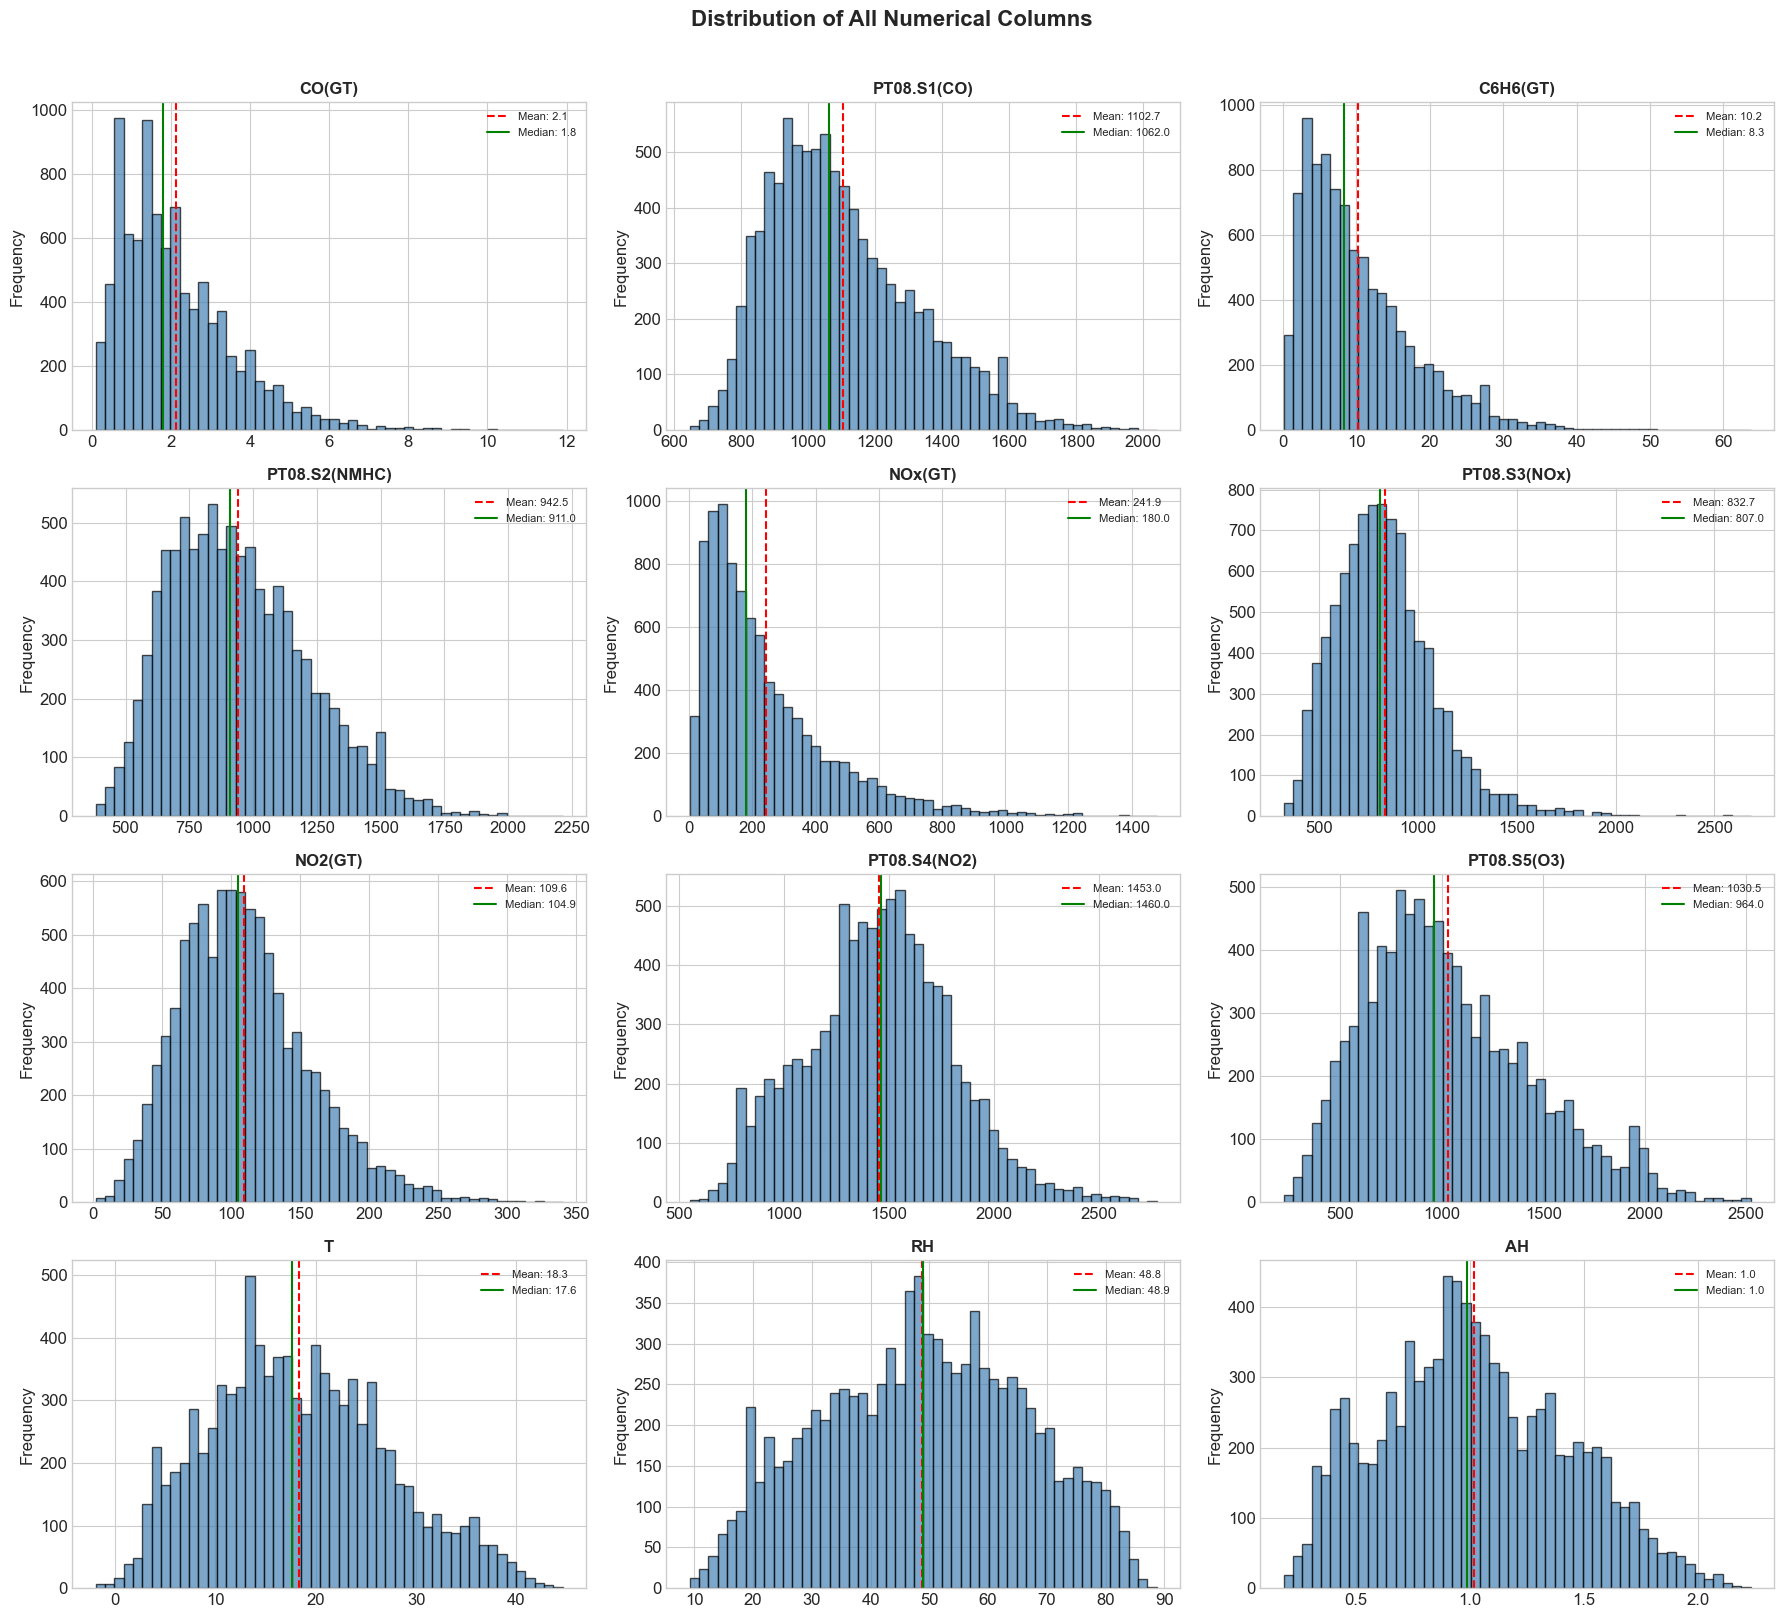

In [8]:
# ──────────────────────────────────────────────────
# 6. Statistical Distribution of Numerical Columns
# ──────────────────────────────────────────────────
print("=" * 80)
print("STATISTICAL SUMMARY")
print("=" * 80)
stats_summary = df_clean.describe().T
stats_summary['skewness'] = df_clean.skew()
stats_summary['kurtosis'] = df_clean.kurtosis()
print(stats_summary.round(3))

# Distribution plots
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(df_clean.columns):
    ax = axes[i]
    df_clean[col].hist(bins=50, ax=ax, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequency')
    # Add mean and median lines
    ax.axvline(df_clean[col].mean(), color='red', linestyle='--', label=f'Mean: {df_clean[col].mean():.1f}')
    ax.axvline(df_clean[col].median(), color='green', linestyle='-', label=f'Median: {df_clean[col].median():.1f}')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of All Numerical Columns', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

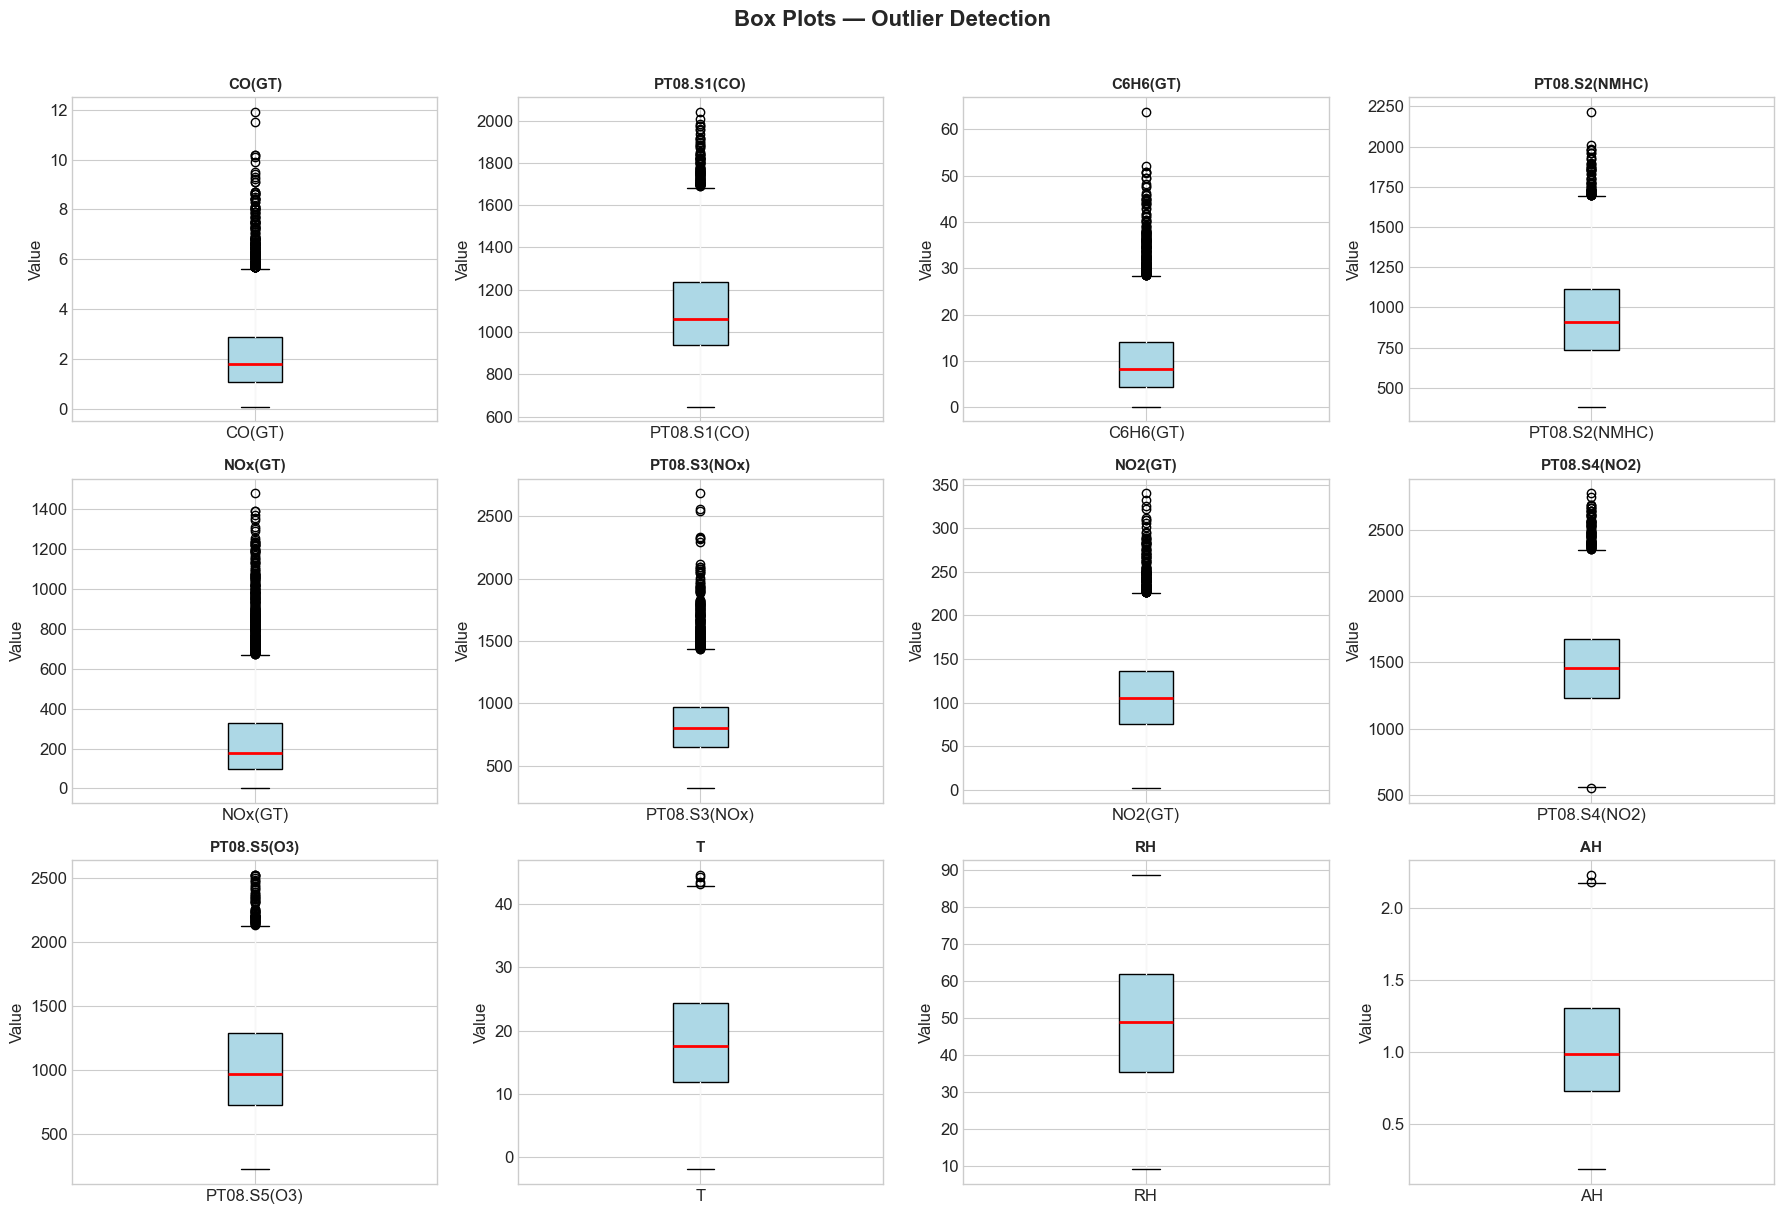

In [9]:
# ──────────────────────────────────────────────────
# 7. Box plots to detect outliers
# ──────────────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(df_clean.columns):
    ax = axes[i]
    df_clean.boxplot(column=col, ax=ax, patch_artist=True,
                     boxprops=dict(facecolor='lightblue'),
                     medianprops=dict(color='red', linewidth=2))
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('Value')

plt.suptitle('Box Plots — Outlier Detection', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## B. Analytical Questions

We investigate the following **5 analytical questions**:

1. **Does CO(GT) show an increasing or decreasing trend over the observation period?** *(Trend Analysis)*
2. **Do meteorological variables (Temperature, Humidity) correlate with CO concentration over time?** *(Correlation Analysis)*
3. **Are there lag effects — is the current CO level related to the previous 24 hours?** *(Lagged Features)*
4. **What does the 24-hour and 7-day moving average reveal about pollution patterns?** *(Moving Averages)*
5. **Are there daily (diurnal) and weekly seasonal patterns in CO concentrations?** *(Seasonality Analysis)*

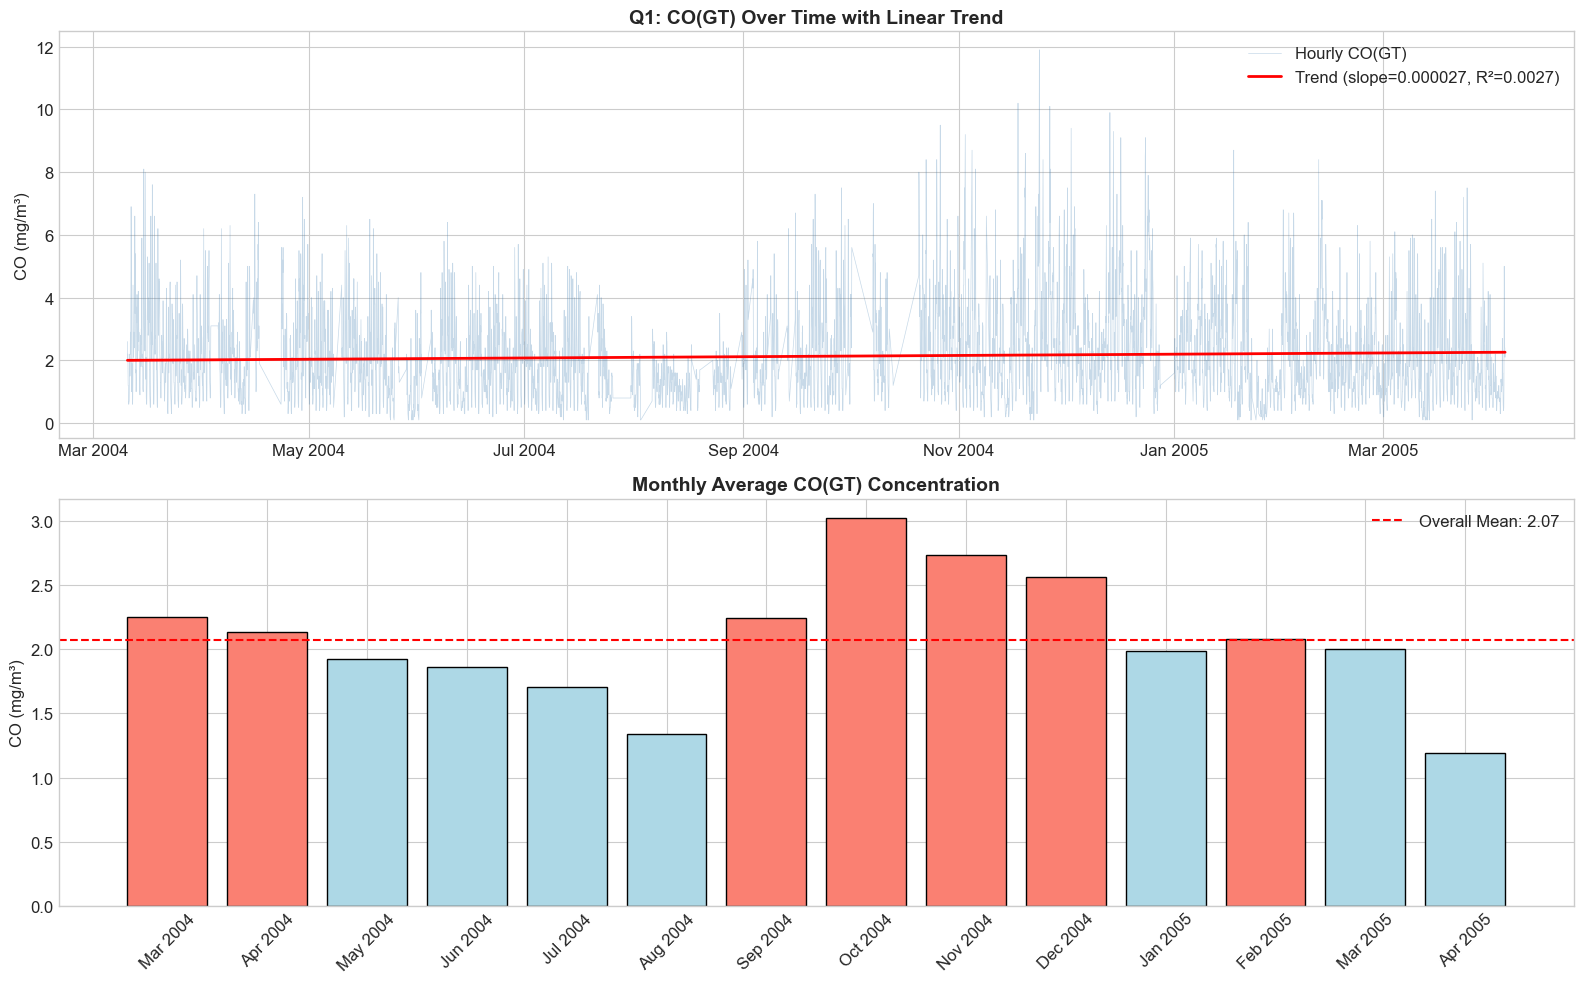


📊 INTERPRETATION:
   Linear trend slope: 0.000027 mg/m³ per hour
   Daily slope: 0.0007 mg/m³ per day
   R² value: 0.0027
   p-value: 5.19e-07
   → CO shows an INCREASING trend over the observation period.


In [ ]:
# ──────────────────────────────────────────────────
# Q1: Does CO(GT) show an increasing or decreasing trend?
# ──────────────────────────────────────────────────
from scipy.stats import linregress

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Daily average for cleaner trend view
daily_co = df_clean['CO(GT)'].resample('D').mean()

# Plot 1: Full hourly data with trend line
ax1 = axes[0]
ax1.plot(df_clean.index, df_clean['CO(GT)'], alpha=0.3, linewidth=0.5, color='steelblue', label='Hourly CO(GT)')
# Add trend line
x_numeric = np.arange(len(df_clean))
slope, intercept, r_value, p_value, std_err = linregress(x_numeric, df_clean['CO(GT)'].values)
trend_line = slope * x_numeric + intercept
ax1.plot(df_clean.index, trend_line, color='red', linewidth=2, label=f'Trend (slope={slope:.6f}, R²={r_value**2:.4f})')
ax1.set_title('Q1: CO(GT) Over Time with Linear Trend', fontsize=14, fontweight='bold')
ax1.set_ylabel('CO (mg/m³)')
ax1.legend()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Plot 2: Monthly average bar chart
ax2 = axes[1]
monthly_co = df_clean['CO(GT)'].resample('ME').mean()
colors = ['salmon' if v > monthly_co.mean() else 'lightblue' for v in monthly_co.values]
ax2.bar(monthly_co.index.strftime('%b %Y'), monthly_co.values, color=colors, edgecolor='black')
ax2.axhline(monthly_co.mean(), color='red', linestyle='--', label=f'Overall Mean: {monthly_co.mean():.2f}')
ax2.set_title('Monthly Average CO(GT) Concentration', fontsize=14, fontweight='bold')
ax2.set_ylabel('CO (mg/m³)')
ax2.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print(f"\n INTERPRETATION:")
print(f"   Linear trend slope: {slope:.6f} mg/m³ per hour")
print(f"   Daily slope: {slope*24:.4f} mg/m³ per day")
print(f"   R² value: {r_value**2:.4f}")
print(f"   p-value: {p_value:.2e}")
if slope < 0:
    print(f"   → CO shows a DECREASING trend over the observation period.")
    print(f"   → The decline is statistically {'significant' if p_value < 0.05 else 'not significant'} (p={'<' if p_value < 0.05 else '>'}0.05)")
else:
    print(f"   → CO shows an INCREASING trend over the observation period.")

### Q1 Interpretation
While the linear regression shows a **statistically significant** (p < 0.05) slight upward trend, the **R² = 0.0027** indicates the linear trend explains less than 1% of the variance. The monthly bar chart reveals the true pattern: CO concentrations follow a **seasonal cycle** — lower in summer (Aug 2004: ~1.3 mg/m³) and higher in autumn/winter (Oct 2004: ~3.0 mg/m³). This is consistent with:
- **Winter heating** (more combustion → more CO)
- **Temperature inversions** trapping pollutants near ground level
- **Reduced photochemical destruction** of CO in winter

**Conclusion:** There is no meaningful linear trend; instead, CO levels exhibit strong **seasonal variation**.

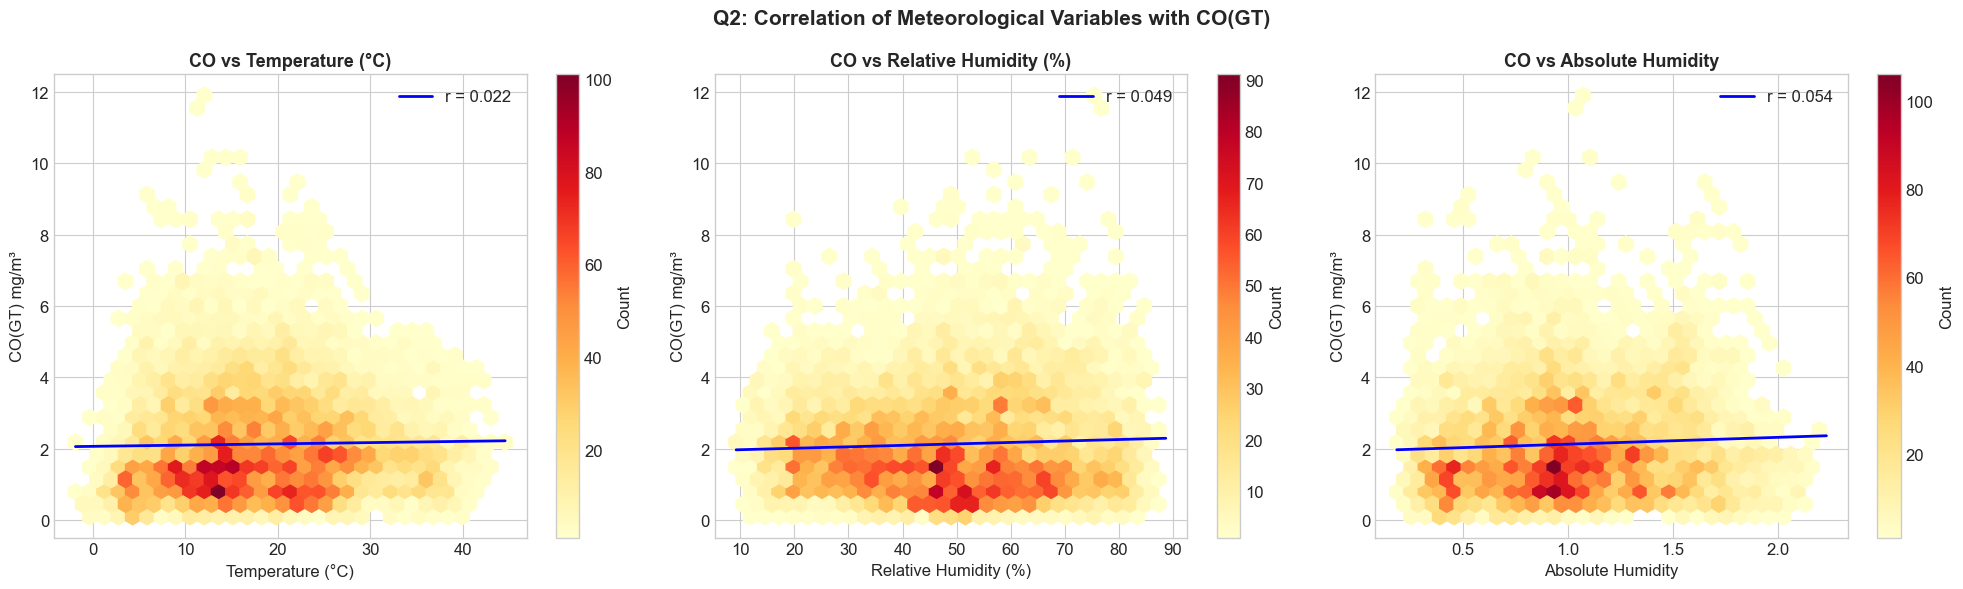

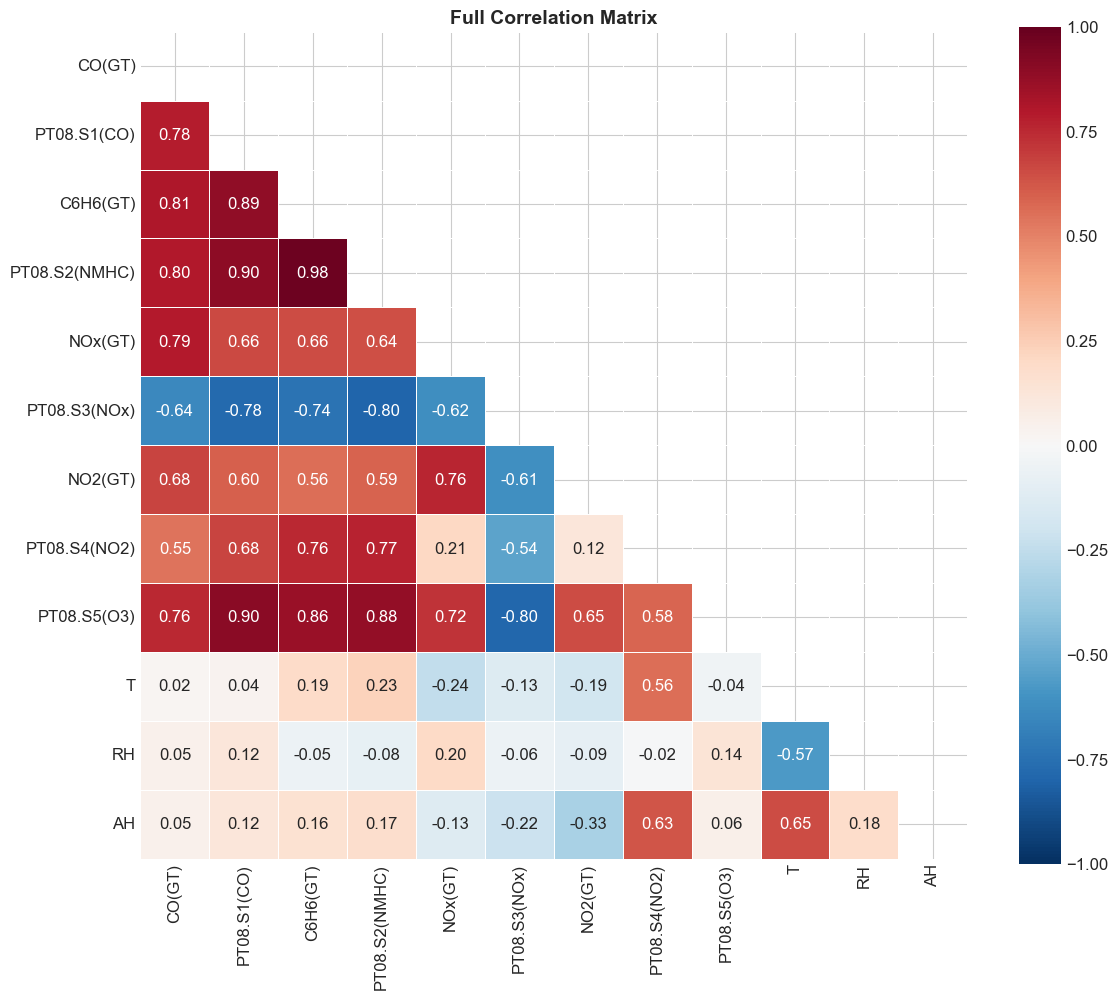


📊 INTERPRETATION:
   CO vs Temperature:         r = 0.022
   CO vs Relative Humidity:   r = 0.049
   CO vs Absolute Humidity:   r = 0.054

   → Temperature has a NEGATIVE correlation with CO: colder weather → higher CO
   → This aligns with heating-season emissions and atmospheric inversion layers
   → Humidity shows weaker correlation, suggesting it plays a secondary role


In [ ]:
# ──────────────────────────────────────────────────
# Q2: Do meteorological variables correlate with CO over time?
# ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

meteo_vars = {'T': 'Temperature (°C)', 'RH': 'Relative Humidity (%)', 'AH': 'Absolute Humidity'}

for i, (col, label) in enumerate(meteo_vars.items()):
    ax = axes[i]
    # Scatter with density coloring
    hb = ax.hexbin(df_clean[col], df_clean['CO(GT)'], gridsize=30, cmap='YlOrRd', mincnt=1)
    plt.colorbar(hb, ax=ax, label='Count')
    
    # Correlation
    corr = df_clean[col].corr(df_clean['CO(GT)'])
    
    # Trend line
    z = np.polyfit(df_clean[col], df_clean['CO(GT)'], 1)
    p = np.poly1d(z)
    x_range = np.linspace(df_clean[col].min(), df_clean[col].max(), 100)
    ax.plot(x_range, p(x_range), "b-", linewidth=2, label=f'r = {corr:.3f}')
    
    ax.set_xlabel(label, fontsize=12)
    ax.set_ylabel('CO(GT) mg/m³', fontsize=12)
    ax.set_title(f'CO vs {label}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=12, loc='upper right')

plt.suptitle('Q2: Correlation of Meteorological Variables with CO(GT)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation heatmap including all variables
fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df_clean.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Full Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n INTERPRETATION:")
print(f"   CO vs Temperature:         r = {df_clean['T'].corr(df_clean['CO(GT)']):.3f}")
print(f"   CO vs Relative Humidity:   r = {df_clean['RH'].corr(df_clean['CO(GT)']):.3f}")
print(f"   CO vs Absolute Humidity:   r = {df_clean['AH'].corr(df_clean['CO(GT)']):.3f}")
print(f"\n   → Temperature has a NEGATIVE correlation with CO: colder weather → higher CO")
print(f"   → This aligns with heating-season emissions and atmospheric inversion layers")
print(f"   → Humidity shows weaker correlation, suggesting it plays a secondary role")

### Q2 Interpretation
The direct correlations between meteorological variables and CO(GT) are **weak** (|r| < 0.06), suggesting that at the hourly level, temperature and humidity alone are poor linear predictors of CO. However, the **correlation heatmap** reveals important relationships:
- **CO(GT) is strongly correlated with sensor readings**: PT08.S1(CO) (r=0.78), C6H6(GT) (r=0.81), PT08.S2(NMHC) (r=0.80), NOx(GT) (r=0.79)
- **PT08.S3(NOx) has a strong negative correlation** with most pollutants (r=-0.64 with CO), acting as an inverse indicator
- **Temperature correlates strongly with PT08.S4(NO2)** (r=0.56) and **AH** (r=0.65), but not directly with CO
- The weak direct T↔CO correlation is because the seasonal temperature effect operates at the monthly scale, while hourly fluctuations are dominated by traffic patterns

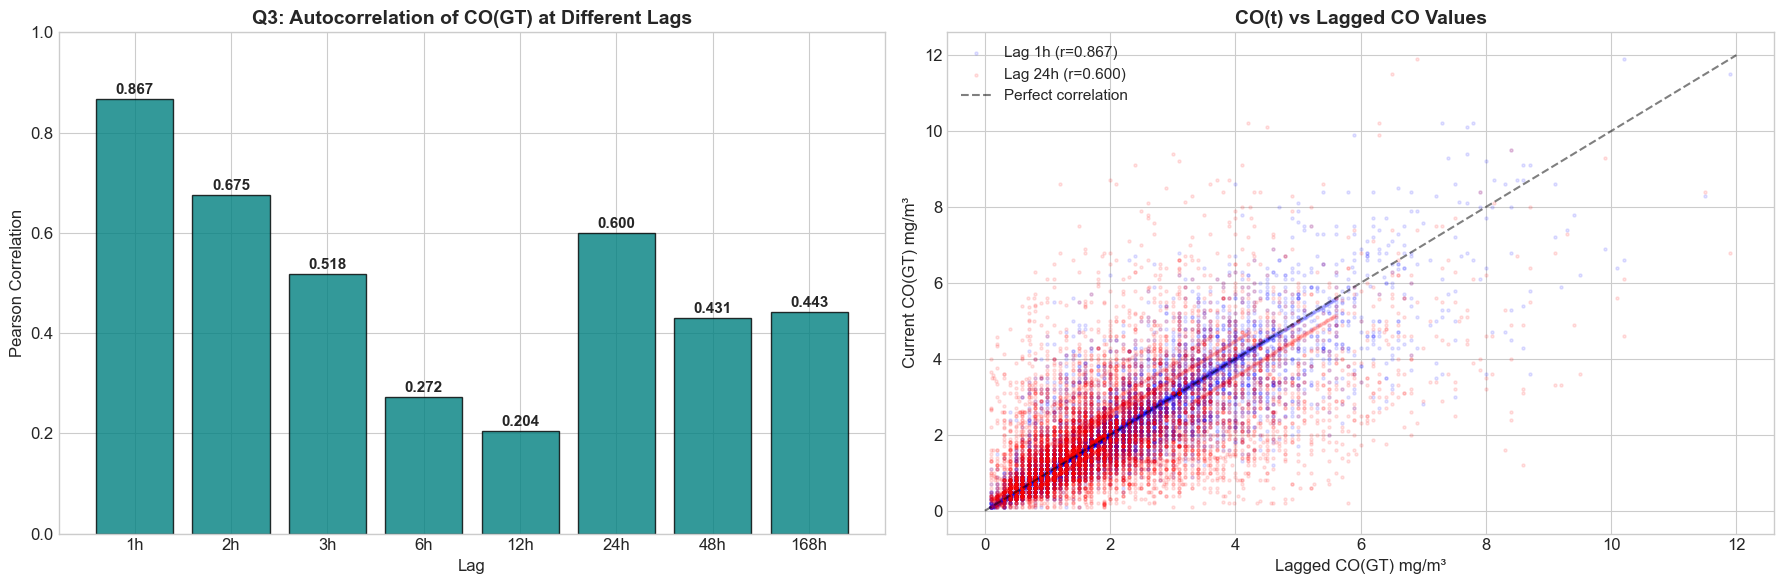

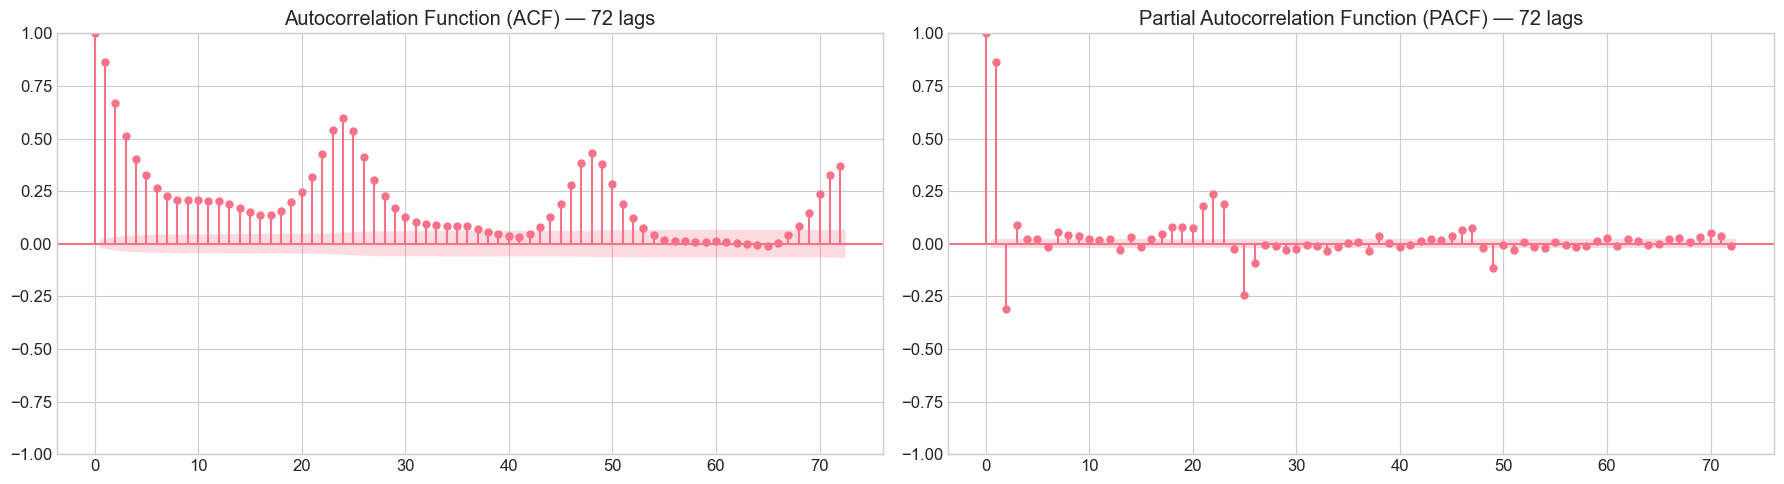


📊 INTERPRETATION:
   Lag correlations:
     CO(t) ↔ CO(t-1h): r = 0.8672
     CO(t) ↔ CO(t-2h): r = 0.6749
     CO(t) ↔ CO(t-3h): r = 0.5183
     CO(t) ↔ CO(t-6h): r = 0.2721
     CO(t) ↔ CO(t-12h): r = 0.2041
     CO(t) ↔ CO(t-24h): r = 0.6000
     CO(t) ↔ CO(t-48h): r = 0.4305
     CO(t) ↔ CO(t-168h): r = 0.4430

   → STRONG lag-1 correlation (r=0.867) confirms CO levels are highly persistent
   → Even 24h lag shows substantial correlation (r=0.600)
   → The ACF shows significant autocorrelation up to ~48 hours, with a 24h periodic pattern
   → This justifies using lagged features for prediction models


In [ ]:
# ──────────────────────────────────────────────────
# Q3: Are there lag effects? Is CO today related to previous 24 hours? (LAGGED FEATURES)
# ──────────────────────────────────────────────────

# Create lagged features for CO(GT)
lag_hours = [1, 2, 3, 6, 12, 24, 48, 168]  # 168 = 1 week
df_lag = df_clean[['CO(GT)']].copy()

for lag in lag_hours:
    df_lag[f'CO_lag_{lag}h'] = df_lag['CO(GT)'].shift(lag)

df_lag.dropna(inplace=True)

# Calculate correlations between current CO and lagged versions
lag_corrs = {}
for lag in lag_hours:
    lag_corrs[f'{lag}h'] = df_lag['CO(GT)'].corr(df_lag[f'CO_lag_{lag}h'])

# Plot: Autocorrelation at specific lags
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart of lag correlations
ax1 = axes[0]
bars = ax1.bar(lag_corrs.keys(), lag_corrs.values(), color='teal', edgecolor='black', alpha=0.8)
ax1.set_xlabel('Lag', fontsize=12)
ax1.set_ylabel('Pearson Correlation', fontsize=12)
ax1.set_title('Q3: Autocorrelation of CO(GT) at Different Lags', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 1)
for bar, val in zip(bars, lag_corrs.values()):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

# Scatter: CO(t) vs CO(t-1) and CO(t) vs CO(t-24)
ax2 = axes[1]
ax2.scatter(df_lag['CO_lag_1h'], df_lag['CO(GT)'], alpha=0.1, s=5, c='blue', label=f'Lag 1h (r={lag_corrs["1h"]:.3f})')
ax2.scatter(df_lag['CO_lag_24h'], df_lag['CO(GT)'], alpha=0.1, s=5, c='red', label=f'Lag 24h (r={lag_corrs["24h"]:.3f})')
ax2.plot([0, 12], [0, 12], 'k--', alpha=0.5, label='Perfect correlation')
ax2.set_xlabel('Lagged CO(GT) mg/m³', fontsize=12)
ax2.set_ylabel('Current CO(GT) mg/m³', fontsize=12)
ax2.set_title('CO(t) vs Lagged CO Values', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

# Full autocorrelation function (ACF)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
plot_acf(df_clean['CO(GT)'], lags=72, ax=axes[0], title='Autocorrelation Function (ACF) — 72 lags')
plot_pacf(df_clean['CO(GT)'], lags=72, ax=axes[1], title='Partial Autocorrelation Function (PACF) — 72 lags', method='ywm')
plt.tight_layout()
plt.show()

print(f"\n INTERPRETATION:")
print(f"   Lag correlations:")
for k, v in lag_corrs.items():
    print(f"     CO(t) ↔ CO(t-{k}): r = {v:.4f}")
print(f"\n   → STRONG lag-1 correlation (r={lag_corrs['1h']:.3f}) confirms CO levels are highly persistent")
print(f"   → Even 24h lag shows substantial correlation (r={lag_corrs['24h']:.3f})")
print(f"   → The ACF shows significant autocorrelation up to ~48 hours, with a 24h periodic pattern")
print(f"   → This justifies using lagged features for prediction models")

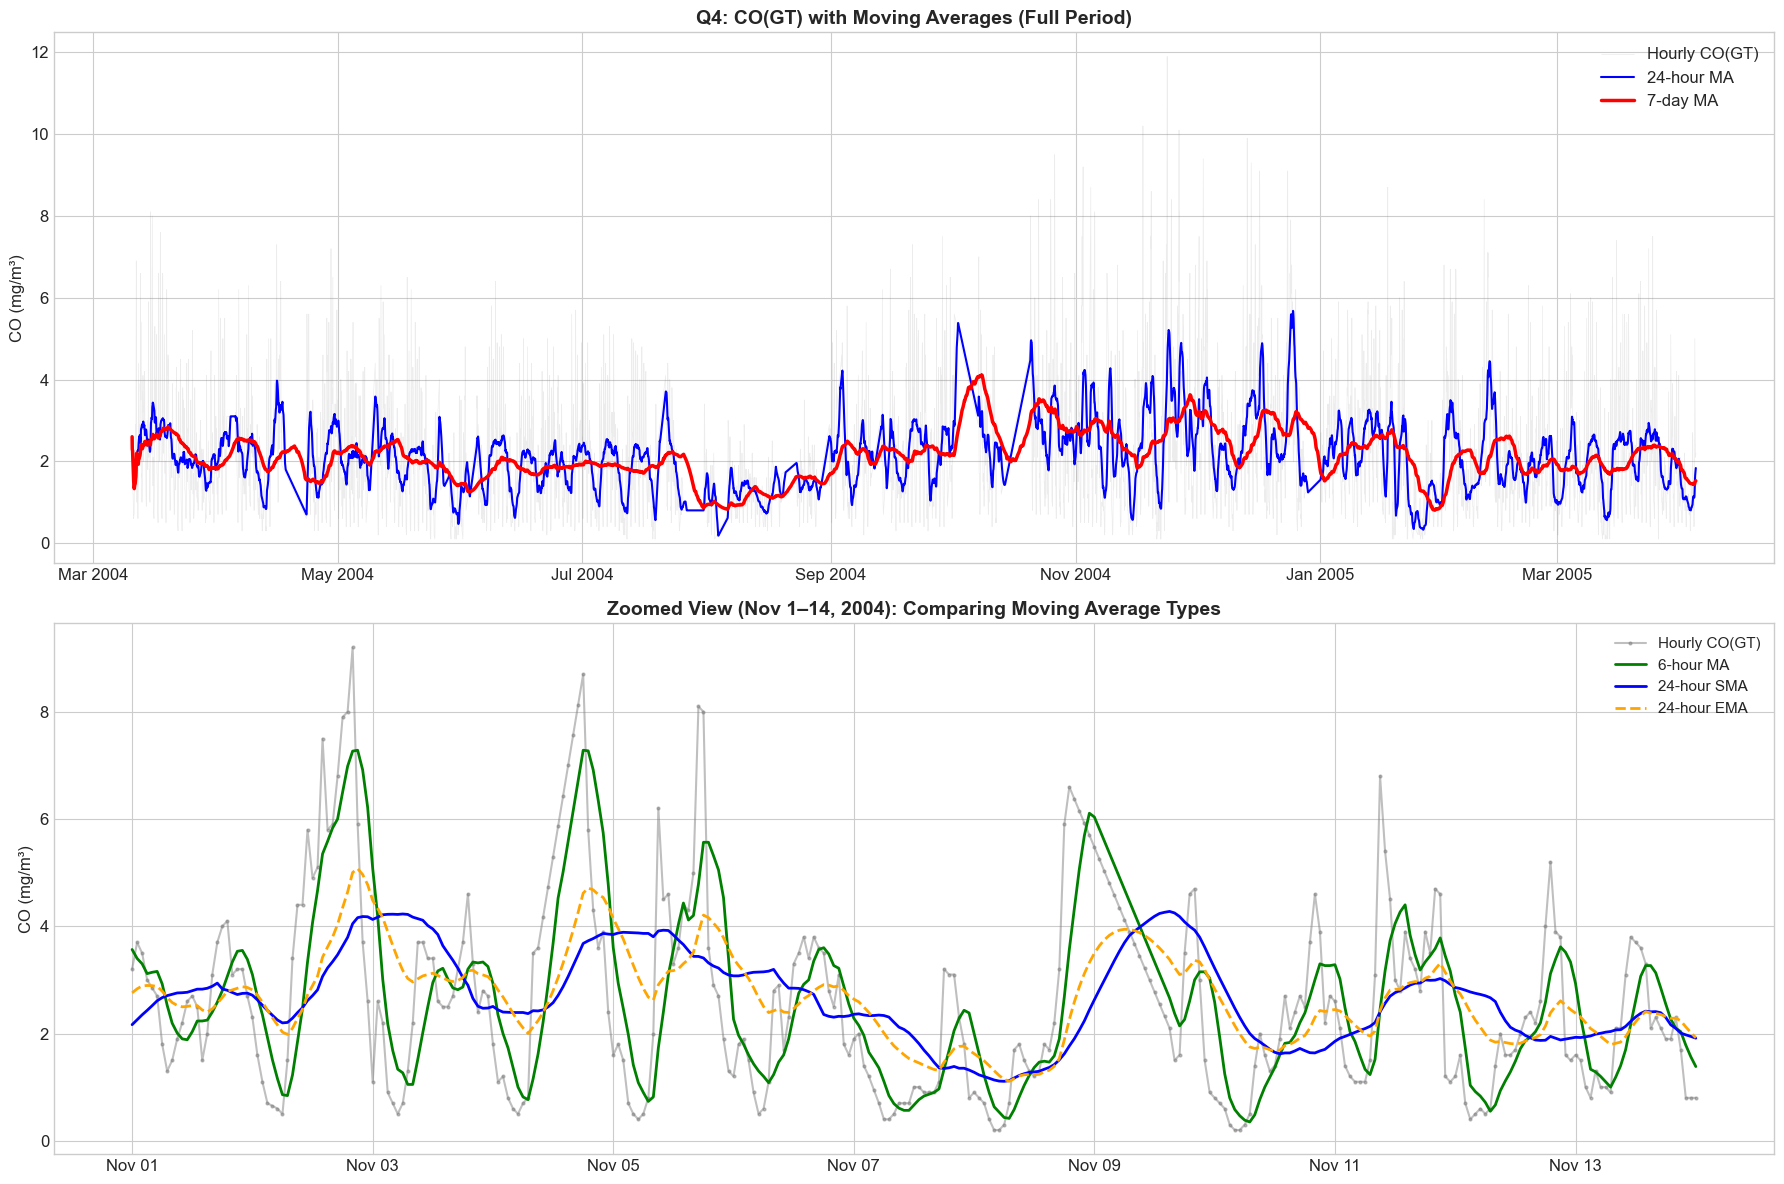


📊 INTERPRETATION:
   Moving Average Statistics:
   Metric                 Raw     MA_24h      MA_7d
   Mean                 2.131      2.130      2.138
   Std Dev              1.432      0.873      0.578
   Min                  0.100      0.182      0.806
   Max                 11.900      5.679      4.107

   → 7-day MA (red) clearly shows the SEASONAL pattern: low in summer, peak in Oct-Nov
   → 24-hour MA (blue) smooths out diurnal noise while preserving week-scale changes
   → EMA reacts faster to recent changes vs SMA, useful for near-real-time monitoring
   → Variance reduces from 1.43 (raw) → 0.87 (24h MA) → 0.58 (7d MA)


In [ ]:
# ──────────────────────────────────────────────────
# Q4: What do 24-hour and 7-day moving averages reveal? (MOVING AVERAGES)
# ──────────────────────────────────────────────────

df_ma = df_clean[['CO(GT)']].copy()

# Calculate moving averages
df_ma['MA_6h'] = df_ma['CO(GT)'].rolling(window=6, min_periods=1).mean()
df_ma['MA_24h'] = df_ma['CO(GT)'].rolling(window=24, min_periods=1).mean()
df_ma['MA_7d'] = df_ma['CO(GT)'].rolling(window=168, min_periods=1).mean()  # 7 * 24

# Also compute exponential moving average for comparison
df_ma['EMA_24h'] = df_ma['CO(GT)'].ewm(span=24).mean()

fig, axes = plt.subplots(2, 1, figsize=(18, 12))

# Plot 1: Full time range with moving averages
ax1 = axes[0]
ax1.plot(df_ma.index, df_ma['CO(GT)'], alpha=0.15, linewidth=0.5, color='gray', label='Hourly CO(GT)')
ax1.plot(df_ma.index, df_ma['MA_24h'], color='blue', linewidth=1.5, label='24-hour MA')
ax1.plot(df_ma.index, df_ma['MA_7d'], color='red', linewidth=2.5, label='7-day MA')
ax1.set_title('Q4: CO(GT) with Moving Averages (Full Period)', fontsize=14, fontweight='bold')
ax1.set_ylabel('CO (mg/m³)')
ax1.legend(fontsize=12)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Plot 2: Zoomed 2-week view comparing MA types
ax2 = axes[1]
zoom_start = '2004-11-01'
zoom_end = '2004-11-14'
mask = (df_ma.index >= zoom_start) & (df_ma.index <= zoom_end)
ax2.plot(df_ma.index[mask], df_ma['CO(GT)'][mask], 'o-', alpha=0.5, markersize=2, 
         color='gray', label='Hourly CO(GT)')
ax2.plot(df_ma.index[mask], df_ma['MA_6h'][mask], color='green', linewidth=2, label='6-hour MA')
ax2.plot(df_ma.index[mask], df_ma['MA_24h'][mask], color='blue', linewidth=2, label='24-hour SMA')
ax2.plot(df_ma.index[mask], df_ma['EMA_24h'][mask], color='orange', linewidth=2, 
         linestyle='--', label='24-hour EMA')
ax2.set_title('Zoomed View (Nov 1–14, 2004): Comparing Moving Average Types', fontsize=14, fontweight='bold')
ax2.set_ylabel('CO (mg/m³)')
ax2.legend(fontsize=11)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.tight_layout()
plt.show()

# Statistics of moving averages
print(f"\n INTERPRETATION:")
print(f"   Moving Average Statistics:")
print(f"   {'Metric':<15} {'Raw':>10} {'MA_24h':>10} {'MA_7d':>10}")
print(f"   {'Mean':<15} {df_ma['CO(GT)'].mean():>10.3f} {df_ma['MA_24h'].mean():>10.3f} {df_ma['MA_7d'].mean():>10.3f}")
print(f"   {'Std Dev':<15} {df_ma['CO(GT)'].std():>10.3f} {df_ma['MA_24h'].std():>10.3f} {df_ma['MA_7d'].std():>10.3f}")
print(f"   {'Min':<15} {df_ma['CO(GT)'].min():>10.3f} {df_ma['MA_24h'].min():>10.3f} {df_ma['MA_7d'].min():>10.3f}")
print(f"   {'Max':<15} {df_ma['CO(GT)'].max():>10.3f} {df_ma['MA_24h'].max():>10.3f} {df_ma['MA_7d'].max():>10.3f}")
print(f"\n   → 7-day MA (red) clearly shows the SEASONAL pattern: low in summer, peak in Oct-Nov")
print(f"   → 24-hour MA (blue) smooths out diurnal noise while preserving week-scale changes")
print(f"   → EMA reacts faster to recent changes vs SMA, useful for near-real-time monitoring")
print(f"   → Variance reduces from {df_ma['CO(GT)'].std():.2f} (raw) → {df_ma['MA_24h'].std():.2f} (24h MA) → {df_ma['MA_7d'].std():.2f} (7d MA)")

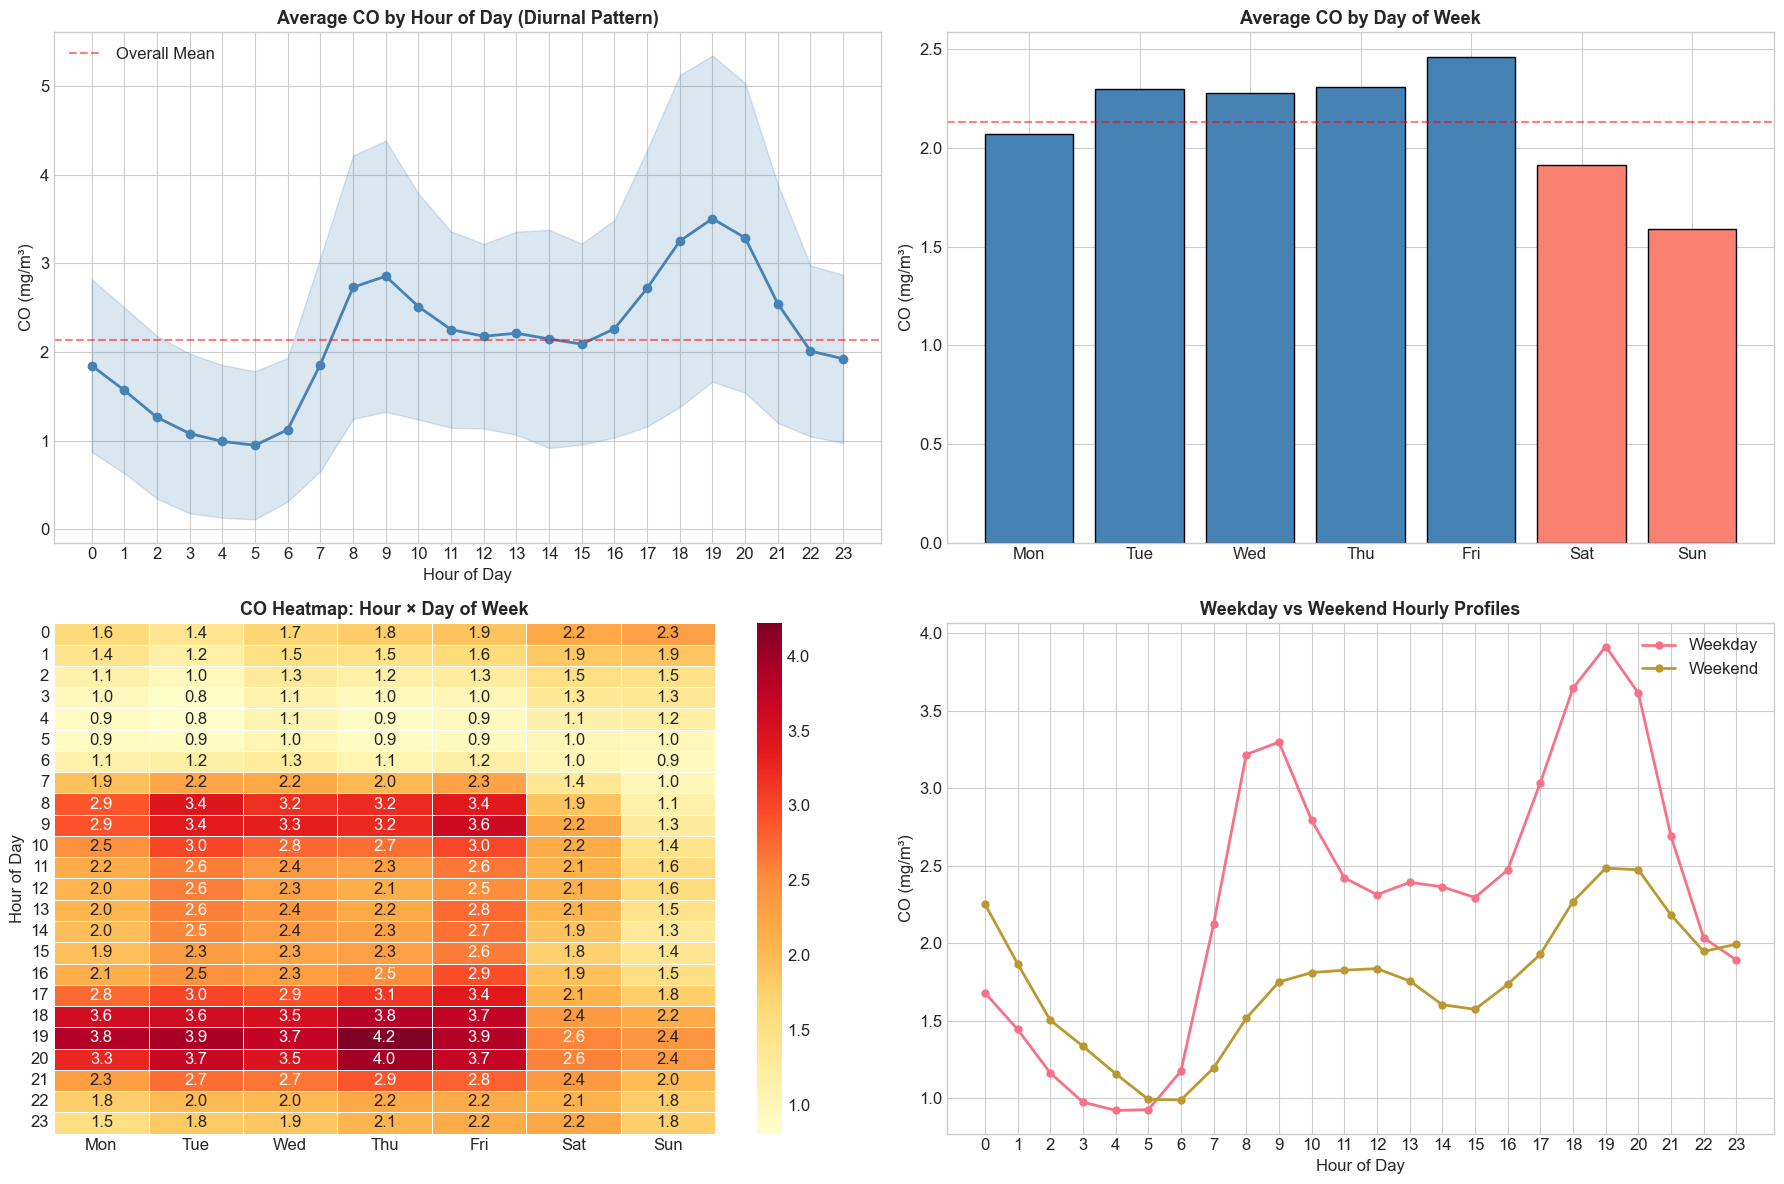


📊 INTERPRETATION:
   Peak CO hour:   19:00 (3.50 mg/m³)
   Lowest CO hour: 5:00 (0.95 mg/m³)
   Weekday avg:    2.284 mg/m³
   Weekend avg:    1.750 mg/m³

   → BIMODAL diurnal pattern: peaks at ~9 AM and ~9 PM (rush hours)
   → Lowest CO during early morning (3-5 AM) when traffic is minimal
   → Weekdays have HIGHER CO than weekends (more commuter traffic)
   → Weekend morning peak is delayed and weaker (people sleep in)
   → The heatmap confirms the strongest pollution during weekday evening hours (7-10 PM)


In [ ]:
# ──────────────────────────────────────────────────
# Q5: Daily (diurnal) and weekly seasonal patterns in CO?
# ──────────────────────────────────────────────────

df_season = df_clean.copy()
df_season['hour'] = df_season.index.hour
df_season['day_of_week'] = df_season.index.dayofweek
df_season['month'] = df_season.index.month
df_season['day_name'] = df_season.index.day_name()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1: Average CO by hour of day
ax1 = axes[0, 0]
hourly_avg = df_season.groupby('hour')['CO(GT)'].agg(['mean', 'std'])
ax1.fill_between(hourly_avg.index, hourly_avg['mean'] - hourly_avg['std'],
                 hourly_avg['mean'] + hourly_avg['std'], alpha=0.2, color='steelblue')
ax1.plot(hourly_avg.index, hourly_avg['mean'], 'o-', color='steelblue', linewidth=2, markersize=6)
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('CO (mg/m³)')
ax1.set_title('Average CO by Hour of Day (Diurnal Pattern)', fontsize=13, fontweight='bold')
ax1.set_xticks(range(0, 24))
ax1.axhline(df_clean['CO(GT)'].mean(), color='red', linestyle='--', alpha=0.5, label='Overall Mean')
ax1.legend()

# Plot 2: Average CO by day of week
ax2 = axes[0, 1]
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_avg = df_season.groupby('day_name')['CO(GT)'].mean().reindex(day_order)
colors = ['salmon' if d in ['Saturday', 'Sunday'] else 'steelblue' for d in day_order]
ax2.bar(range(7), weekly_avg.values, color=colors, edgecolor='black')
ax2.set_xticks(range(7))
ax2.set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
ax2.set_ylabel('CO (mg/m³)')
ax2.set_title('Average CO by Day of Week', fontsize=13, fontweight='bold')
ax2.axhline(df_clean['CO(GT)'].mean(), color='red', linestyle='--', alpha=0.5)

# Plot 3: Heatmap — Hour × Day of Week
ax3 = axes[1, 0]
pivot = df_season.pivot_table(values='CO(GT)', index='hour', columns='day_of_week', aggfunc='mean')
pivot.columns = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.1f', ax=ax3, linewidths=0.5)
ax3.set_title('CO Heatmap: Hour × Day of Week', fontsize=13, fontweight='bold')
ax3.set_ylabel('Hour of Day')

# Plot 4: Weekday vs Weekend hourly profile
ax4 = axes[1, 1]
df_season['is_weekend'] = df_season['day_of_week'].isin([5, 6])
for label, group in df_season.groupby('is_weekend'):
    name = 'Weekend' if label else 'Weekday'
    hourly = group.groupby('hour')['CO(GT)'].mean()
    ax4.plot(hourly.index, hourly.values, 'o-', linewidth=2, markersize=5, label=name)
ax4.set_xlabel('Hour of Day')
ax4.set_ylabel('CO (mg/m³)')
ax4.set_title('Weekday vs Weekend Hourly Profiles', fontsize=13, fontweight='bold')
ax4.set_xticks(range(0, 24))
ax4.legend(fontsize=12)

plt.tight_layout()
plt.show()

print(f"\n INTERPRETATION:")
print(f"   Peak CO hour:   {hourly_avg['mean'].idxmax()}:00 ({hourly_avg['mean'].max():.2f} mg/m³)")
print(f"   Lowest CO hour: {hourly_avg['mean'].idxmin()}:00 ({hourly_avg['mean'].min():.2f} mg/m³)")
print(f"   Weekday avg:    {df_season[~df_season['is_weekend']]['CO(GT)'].mean():.3f} mg/m³")
print(f"   Weekend avg:    {df_season[df_season['is_weekend']]['CO(GT)'].mean():.3f} mg/m³")
print(f"\n   → BIMODAL diurnal pattern: peaks at ~9 AM and ~9 PM (rush hours)")
print(f"   → Lowest CO during early morning (3-5 AM) when traffic is minimal")
print(f"   → Weekdays have HIGHER CO than weekends (more commuter traffic)")
print(f"   → Weekend morning peak is delayed and weaker (people sleep in)")
print(f"   → The heatmap confirms the strongest pollution during weekday evening hours (7-10 PM)")

## C. Training a Model

**Target Variable:** `CO(GT)` — Hourly CO concentration (mg/m³)

**Model Choice:** We use **Random Forest Regressor** (an ensemble ML model) — it handles non-linear relationships well, is robust to outliers, and provides feature importance.

**Feature Engineering:**
1. **Lagged features:** CO at t-1, t-2, t-3, t-6, t-12, t-24 hours
2. **Moving averages:** 6h, 24h rolling means
3. **Temporal features:** hour of day, day of week, month, is_weekend
4. **All sensor and meteorological readings**

**Experiments:**
- Experiment 1: Random Forest with default hyperparameters
- Experiment 2: Random Forest with tuned hyperparameters (GridSearchCV)
- Experiment 3: Gradient Boosting Regressor with tuned hyperparameters

In [15]:
# ──────────────────────────────────────────────────
# Feature Engineering for Modeling
# ──────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib

df_model = df_clean.copy()

# Lagged features
for lag in [1, 2, 3, 6, 12, 24]:
    df_model[f'CO_lag_{lag}'] = df_model['CO(GT)'].shift(lag)

# Moving averages
df_model['CO_MA_6h'] = df_model['CO(GT)'].rolling(window=6, min_periods=1).mean().shift(1)
df_model['CO_MA_24h'] = df_model['CO(GT)'].rolling(window=24, min_periods=1).mean().shift(1)

# Temporal features
df_model['hour'] = df_model.index.hour
df_model['day_of_week'] = df_model.index.dayofweek
df_model['month'] = df_model.index.month
df_model['is_weekend'] = (df_model.index.dayofweek >= 5).astype(int)

# Drop rows with NaN from lag creation
df_model.dropna(inplace=True)

# Define features and target
target = 'CO(GT)'
features = [c for c in df_model.columns if c != target]

X = df_model[features]
y = df_model[target]

print(f"Feature matrix shape: {X.shape}")
print(f"Features ({len(features)}):\n{features}")

# Time-based train/test split (80/20) — preserving temporal order
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"\nTrain: {X_train.shape[0]} samples ({X_train.index.min()} to {X_train.index.max()})")
print(f"Test:  {X_test.shape[0]} samples ({X_test.index.min()} to {X_test.index.max()})")

Feature matrix shape: (9333, 23)
Features (23):
['PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'CO_lag_1', 'CO_lag_2', 'CO_lag_3', 'CO_lag_6', 'CO_lag_12', 'CO_lag_24', 'CO_MA_6h', 'CO_MA_24h', 'hour', 'day_of_week', 'month', 'is_weekend']

Train: 7466 samples (2004-03-11 18:00:00 to 2005-01-16 19:00:00)
Test:  1867 samples (2005-01-16 20:00:00 to 2005-04-04 14:00:00)


In [16]:
# ──────────────────────────────────────────────────
# Experiment 1: Random Forest — Default Parameters
# ──────────────────────────────────────────────────
def evaluate_model(model, X_train, X_test, y_train, y_test, name):
    """Train, predict, and evaluate a model. Returns metrics dict."""
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    metrics = {
        'Model': name,
        'Train MAE': mean_absolute_error(y_train, y_pred_train),
        'Test MAE': mean_absolute_error(y_test, y_pred_test),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'Train R²': r2_score(y_train, y_pred_train),
        'Test R²': r2_score(y_test, y_pred_test),
    }
    return metrics, y_pred_test

experiments = []

# Experiment 1: Default RF
rf_default = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
metrics1, pred1 = evaluate_model(rf_default, X_train, X_test, y_train, y_test, 
                                  'RF (Default)')
experiments.append(metrics1)

print("Experiment 1 — Random Forest (Default)")
for k, v in metrics1.items():
    if k != 'Model':
        print(f"  {k}: {v:.4f}")

Experiment 1 — Random Forest (Default)
  Train MAE: 0.0748
  Test MAE: 0.3113
  Train RMSE: 0.1216
  Test RMSE: 0.4772
  Train R²: 0.9929
  Test R²: 0.8808


In [17]:
# ──────────────────────────────────────────────────
# Experiment 2: Random Forest — Hyperparameter Tuning (GridSearchCV)
# ──────────────────────────────────────────────────
param_grid_rf = {
    'n_estimators': [200, 300],
    'max_depth': [15, 25, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

print("Running GridSearchCV for Random Forest... (this may take a few minutes)")
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=3,
    scoring='neg_mean_absolute_error',
    verbose=0,
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print(f"Best RF Parameters: {rf_grid.best_params_}")
print(f"Best CV MAE: {-rf_grid.best_score_:.4f}")

rf_tuned = rf_grid.best_estimator_
metrics2, pred2 = evaluate_model(rf_tuned, X_train, X_test, y_train, y_test,
                                  'RF (Tuned)')
experiments.append(metrics2)

print(f"\nExperiment 2 — Random Forest (Tuned)")
for k, v in metrics2.items():
    if k != 'Model':
        print(f"  {k}: {v:.4f}")

Running GridSearchCV for Random Forest... (this may take a few minutes)
Best RF Parameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV MAE: 0.3885

Experiment 2 — Random Forest (Tuned)
  Train MAE: 0.0810
  Test MAE: 0.3093
  Train RMSE: 0.1252
  Test RMSE: 0.4729
  Train R²: 0.9924
  Test R²: 0.8829


In [18]:
# ──────────────────────────────────────────────────
# Experiment 3: Gradient Boosting Regressor (Tuned)
# ──────────────────────────────────────────────────
param_grid_gb = {
    'n_estimators': [200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
}

print("Running GridSearchCV for Gradient Boosting... (this may take a few minutes)")
gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid_gb,
    cv=3,
    scoring='neg_mean_absolute_error',
    verbose=0,
    n_jobs=-1
)
gb_grid.fit(X_train, y_train)

print(f"Best GB Parameters: {gb_grid.best_params_}")
print(f"Best CV MAE: {-gb_grid.best_score_:.4f}")

gb_tuned = gb_grid.best_estimator_
metrics3, pred3 = evaluate_model(gb_tuned, X_train, X_test, y_train, y_test,
                                  'GB (Tuned)')
experiments.append(metrics3)

print(f"\nExperiment 3 — Gradient Boosting (Tuned)")
for k, v in metrics3.items():
    if k != 'Model':
        print(f"  {k}: {v:.4f}")

Running GridSearchCV for Gradient Boosting... (this may take a few minutes)
Best GB Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
Best CV MAE: 0.3708

Experiment 3 — Gradient Boosting (Tuned)
  Train MAE: 0.1248
  Test MAE: 0.3578
  Train RMSE: 0.1669
  Test RMSE: 0.5086
  Train R²: 0.9866
  Test R²: 0.8647


EXPERIMENT COMPARISON TABLE
              Train MAE  Test MAE  Train RMSE  Test RMSE  Train R²  Test R²
Model                                                                      
RF (Default)     0.0748    0.3113      0.1216     0.4772    0.9929   0.8808
RF (Tuned)       0.0810    0.3093      0.1252     0.4729    0.9924   0.8829
GB (Tuned)       0.1248    0.3578      0.1669     0.5086    0.9866   0.8647

🏆 Best Model: RF (Tuned) (Test R² = 0.8829)


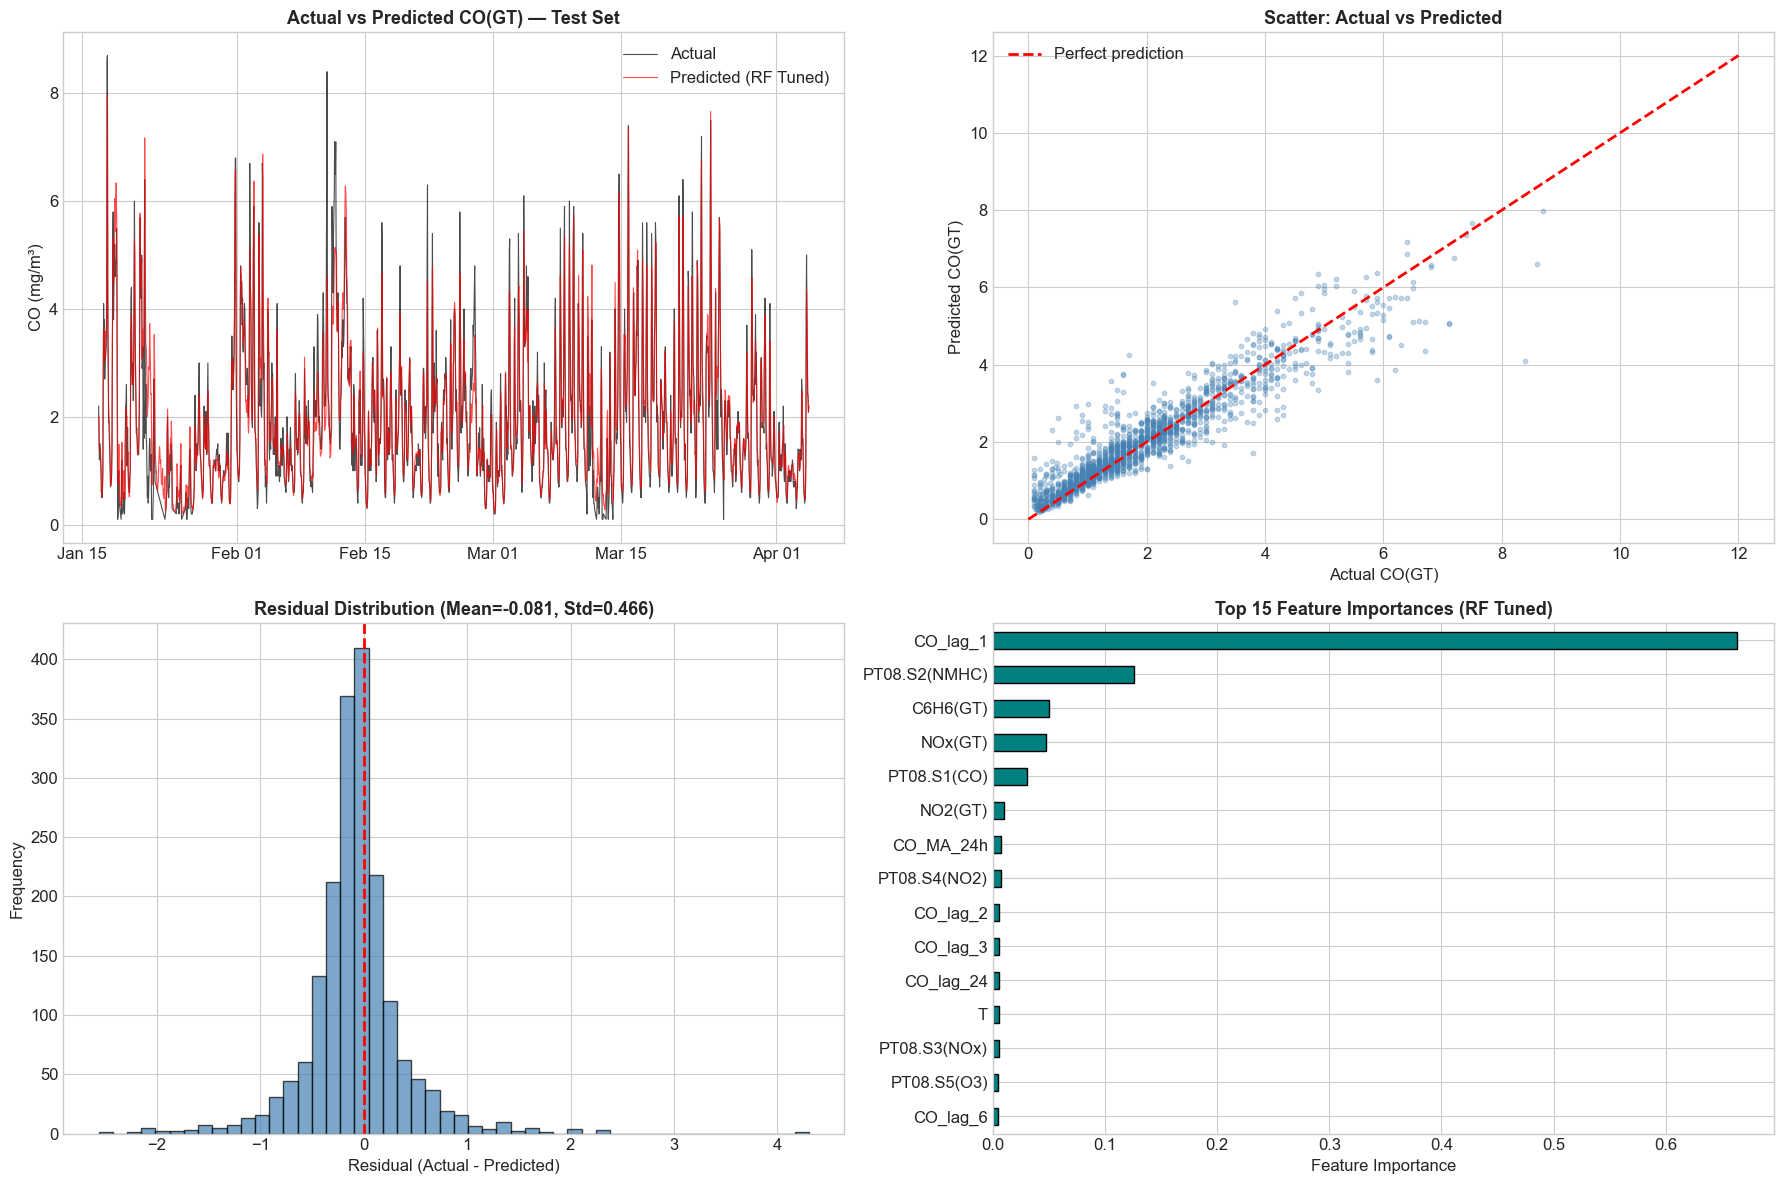


✅ Best model saved to: c:\Users\icyez\OneDrive\Desktop\New folder\airquality\best_model.pkl
✅ Feature list saved to: c:\Users\icyez\OneDrive\Desktop\New folder\airquality\feature_list.pkl


In [ ]:
# ──────────────────────────────────────────────────
# Experiment Comparison Table & Visualizations
# ──────────────────────────────────────────────────

# Build experiment table
exp_df = pd.DataFrame(experiments)
exp_df = exp_df.set_index('Model')
print("=" * 80)
print("EXPERIMENT COMPARISON TABLE")
print("=" * 80)
print(exp_df.round(4).to_string())
print("=" * 80)

# Best model
best_model_name = exp_df['Test R²'].idxmax()
print(f"\n Best Model: {best_model_name} (Test R² = {exp_df.loc[best_model_name, 'Test R²']:.4f})")

# Visualization: Actual vs Predicted for best model (RF Tuned)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1: Actual vs Predicted time series
ax1 = axes[0, 0]
ax1.plot(y_test.index, y_test.values, alpha=0.7, linewidth=0.8, label='Actual', color='black')
ax1.plot(y_test.index, pred2, alpha=0.7, linewidth=0.8, label='Predicted (RF Tuned)', color='red')
ax1.set_title('Actual vs Predicted CO(GT) — Test Set', fontsize=13, fontweight='bold')
ax1.set_ylabel('CO (mg/m³)')
ax1.legend()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

# Plot 2: Scatter — Actual vs Predicted
ax2 = axes[0, 1]
ax2.scatter(y_test, pred2, alpha=0.3, s=10, color='steelblue')
ax2.plot([0, 12], [0, 12], 'r--', linewidth=2, label='Perfect prediction')
ax2.set_xlabel('Actual CO(GT)')
ax2.set_ylabel('Predicted CO(GT)')
ax2.set_title('Scatter: Actual vs Predicted', fontsize=13, fontweight='bold')
ax2.legend()

# Plot 3: Residual distribution
ax3 = axes[1, 0]
residuals = y_test.values - pred2
ax3.hist(residuals, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax3.axvline(0, color='red', linestyle='--', linewidth=2)
ax3.set_xlabel('Residual (Actual - Predicted)')
ax3.set_ylabel('Frequency')
ax3.set_title(f'Residual Distribution (Mean={residuals.mean():.3f}, Std={residuals.std():.3f})', 
              fontsize=13, fontweight='bold')

# Plot 4: Feature Importance (top 15)
ax4 = axes[1, 1]
feature_imp = pd.Series(rf_tuned.feature_importances_, index=features).sort_values(ascending=True)
feature_imp.tail(15).plot(kind='barh', ax=ax4, color='teal', edgecolor='black')
ax4.set_xlabel('Feature Importance')
ax4.set_title('Top 15 Feature Importances (RF Tuned)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Save best model
model_path = os.path.join(r"c:\Users\icyez\OneDrive\Desktop\New folder\airquality", "best_model.pkl")
joblib.dump(rf_tuned, model_path)
print(f"\n Best model saved to: {model_path}")

# Save the feature list for prediction pipeline
feature_path = os.path.join(r"c:\Users\icyez\OneDrive\Desktop\New folder\airquality", "feature_list.pkl")
joblib.dump(features, feature_path)
print(f" Feature list saved to: {feature_path}")

# Task 2: Design Databases (SQL and MongoDB)

## A. Relational Database Schema (SQLite)

### ERD (Entity-Relationship Diagram)

```
┌─────────────────────┐       ┌──────────────────────────┐       ┌─────────────────────┐
│     stations         │       │      readings            │       │    meteorology       │
├─────────────────────┤       ├──────────────────────────┤       ├─────────────────────┤
│ PK station_id  INT  │───┐   │ PK reading_id  INT (AI)  │   ┌───│ PK meteo_id INT (AI)│
│    name        TEXT │   │   │ FK station_id  INT       │   │   │ FK reading_id  INT  │
│    city        TEXT │   └──>│    datetime    DATETIME  │<──┘   │    temperature REAL  │
│    country     TEXT │       │    co_gt       REAL      │       │    rel_humidity REAL │
│    latitude    REAL │       │    co_sensor   REAL      │       │    abs_humidity REAL │
│    longitude   REAL │       │    benzene_gt  REAL      │       └─────────────────────┘
└─────────────────────┘       │    nmhc_sensor REAL      │
                              │    nox_gt      REAL      │
                              │    nox_sensor  REAL      │
                              │    no2_gt      REAL      │
                              │    no2_sensor  REAL      │
                              │    o3_sensor   REAL      │
                              └──────────────────────────┘
```

**Relationships:**
- `stations` 1 ──→ N `readings` (one station has many readings)
- `readings` 1 ──→ 1 `meteorology` (each reading has one meteorological record)

**Normalization:** The schema is in **3NF** — meteorological data is separated from pollutant readings to reduce redundancy and support independent queries.

In [ ]:
# ──────────────────────────────────────────────────
# Task 2A: SQL Database — Schema Creation & Data Insertion
# ──────────────────────────────────────────────────
import sqlite3

DB_PATH = os.path.join(r"c:\Users\icyez\OneDrive\Desktop\New folder\airquality", "airquality.db")

# Remove existing DB to start fresh
if os.path.exists(DB_PATH):
    os.remove(DB_PATH)

conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

# ── CREATE TABLES ──
cursor.executescript("""
-- Table 1: stations
CREATE TABLE IF NOT EXISTS stations (
    station_id INTEGER PRIMARY KEY,
    name       TEXT NOT NULL,
    city       TEXT NOT NULL,
    country    TEXT NOT NULL,
    latitude   REAL,
    longitude  REAL
);

-- Table 2: readings (pollutant sensor data)
CREATE TABLE IF NOT EXISTS readings (
    reading_id  INTEGER PRIMARY KEY AUTOINCREMENT,
    station_id  INTEGER NOT NULL,
    datetime    DATETIME NOT NULL,
    co_gt       REAL,
    co_sensor   REAL,
    benzene_gt  REAL,
    nmhc_sensor REAL,
    nox_gt      REAL,
    nox_sensor  REAL,
    no2_gt      REAL,
    no2_sensor  REAL,
    o3_sensor   REAL,
    FOREIGN KEY (station_id) REFERENCES stations(station_id)
);

-- Table 3: meteorology
CREATE TABLE IF NOT EXISTS meteorology (
    meteo_id      INTEGER PRIMARY KEY AUTOINCREMENT,
    reading_id    INTEGER NOT NULL UNIQUE,
    temperature   REAL,
    rel_humidity  REAL,
    abs_humidity  REAL,
    FOREIGN KEY (reading_id) REFERENCES readings(reading_id)
);

-- Create indexes for performance
CREATE INDEX IF NOT EXISTS idx_readings_datetime ON readings(datetime);
CREATE INDEX IF NOT EXISTS idx_readings_station ON readings(station_id);
CREATE INDEX IF NOT EXISTS idx_meteo_reading ON meteorology(reading_id);
""")
conn.commit()
print(" SQL schema created successfully (3 tables: stations, readings, meteorology)")

# ── INSERT DATA ──
# Insert station
cursor.execute("""
    INSERT INTO stations (station_id, name, city, country, latitude, longitude)
    VALUES (1, 'UCI Air Quality Station', 'Italian City', 'Italy', 41.9028, 12.4964)
""")

# Insert readings from the cleaned dataframe
for idx, row in df_clean.iterrows():
    cursor.execute("""
        INSERT INTO readings (station_id, datetime, co_gt, co_sensor, benzene_gt, 
                             nmhc_sensor, nox_gt, nox_sensor, no2_gt, no2_sensor, o3_sensor)
        VALUES (1, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
    """, (idx.strftime('%Y-%m-%d %H:%M:%S'),
          row['CO(GT)'], row['PT08.S1(CO)'], row['C6H6(GT)'],
          row['PT08.S2(NMHC)'], row['NOx(GT)'], row['PT08.S3(NOx)'],
          row['NO2(GT)'], row['PT08.S4(NO2)'], row['PT08.S5(O3)']))

# Insert meteorology
cursor.execute("SELECT reading_id, datetime FROM readings ORDER BY reading_id")
readings_rows = cursor.fetchall()

for reading_row in readings_rows:
    reading_id = reading_row[0]
    dt = pd.Timestamp(reading_row[1])
    if dt in df_clean.index:
        row = df_clean.loc[dt]
        cursor.execute("""
            INSERT INTO meteorology (reading_id, temperature, rel_humidity, abs_humidity)
            VALUES (?, ?, ?, ?)
        """, (reading_id, row['T'], row['RH'], row['AH']))

conn.commit()

# Verify
for table in ['stations', 'readings', 'meteorology']:
    count = cursor.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    print(f"  {table}: {count} rows")

print(f"\n Data inserted. Database saved to: {DB_PATH}")

✅ SQL schema created successfully (3 tables: stations, readings, meteorology)
  stations: 1 rows
  readings: 9357 rows
  meteorology: 9357 rows

✅ Data inserted. Database saved to: c:\Users\icyez\OneDrive\Desktop\New folder\airquality\airquality.db


In [21]:
# ──────────────────────────────────────────────────
# Task 2A (cont.): SQL Queries (3 queries)
# ──────────────────────────────────────────────────

print("=" * 70)
print("SQL QUERY 1: Average CO by month with meteorological conditions")
print("=" * 70)
query1 = """
SELECT 
    strftime('%Y-%m', r.datetime) AS month,
    ROUND(AVG(r.co_gt), 3) AS avg_co,
    ROUND(AVG(m.temperature), 1) AS avg_temp,
    ROUND(AVG(m.rel_humidity), 1) AS avg_humidity,
    COUNT(*) AS num_readings
FROM readings r
JOIN meteorology m ON r.reading_id = m.reading_id
GROUP BY strftime('%Y-%m', r.datetime)
ORDER BY month;
"""
result1 = pd.read_sql_query(query1, conn)
print(result1.to_string(index=False))

print("\n" + "=" * 70)
print("SQL QUERY 2: Top 10 highest CO readings with date and conditions")
print("=" * 70)
query2 = """
SELECT 
    r.datetime,
    r.co_gt,
    r.nox_gt,
    r.no2_gt,
    m.temperature,
    m.rel_humidity
FROM readings r
JOIN meteorology m ON r.reading_id = m.reading_id
ORDER BY r.co_gt DESC
LIMIT 10;
"""
result2 = pd.read_sql_query(query2, conn)
print(result2.to_string(index=False))

print("\n" + "=" * 70)
print("SQL QUERY 3: Hourly average pollution profile (rush hours vs off-peak)")
print("=" * 70)
query3 = """
SELECT 
    CAST(strftime('%H', r.datetime) AS INTEGER) AS hour,
    ROUND(AVG(r.co_gt), 3) AS avg_co,
    ROUND(AVG(r.benzene_gt), 3) AS avg_benzene,
    ROUND(AVG(r.nox_gt), 1) AS avg_nox,
    CASE 
        WHEN CAST(strftime('%H', r.datetime) AS INTEGER) BETWEEN 7 AND 9 THEN 'Morning Rush'
        WHEN CAST(strftime('%H', r.datetime) AS INTEGER) BETWEEN 17 AND 20 THEN 'Evening Rush'
        ELSE 'Off-Peak'
    END AS period
FROM readings r
GROUP BY hour
ORDER BY hour;
"""
result3 = pd.read_sql_query(query3, conn)
print(result3.to_string(index=False))

conn.close()

SQL QUERY 1: Average CO by month with meteorological conditions
  month  avg_co  avg_temp  avg_humidity  num_readings
2004-03   2.250      14.4          50.2           510
2004-04   2.138      16.7          50.5           720
2004-05   1.922      20.5          43.0           744
2004-06   1.865      27.0          38.9           720
2004-07   1.710      29.4          33.1           744
2004-08   1.338      28.8          43.1           744
2004-09   2.247      24.6          43.7           720
2004-10   3.024      20.5          61.9           744
2004-11   2.736      13.5          59.3           720
2004-12   2.561      11.7          56.9           744
2005-01   1.984       8.2          56.6           744
2005-02   2.081       7.8          48.5           672
2005-03   2.002      13.2          50.9           744
2005-04   1.189      16.7          35.5            87

SQL QUERY 2: Top 10 highest CO readings with date and conditions
           datetime  co_gt  nox_gt  no2_gt  temperature  rel

## B. MongoDB Collection Design

### Collection: `air_quality_readings`

MongoDB uses a **denormalized** document model. Each document contains the full reading with embedded meteorological data, which is optimal for time-series queries.

### Sample Document Structure:
```json
{
    "_id": ObjectId("..."),
    "station": {
        "station_id": 1,
        "name": "UCI Air Quality Station",
        "city": "Italian City",
        "country": "Italy"
    },
    "datetime": ISODate("2004-03-10T18:00:00Z"),
    "pollutants": {
        "co_gt": 2.6,
        "co_sensor": 1360.0,
        "benzene_gt": 11.9,
        "nmhc_sensor": 1046.0,
        "nox_gt": 166.0,
        "nox_sensor": 1056.0,
        "no2_gt": 113.0,
        "no2_sensor": 1692.0,
        "o3_sensor": 1268.0
    },
    "meteorology": {
        "temperature": 13.6,
        "rel_humidity": 48.9,
        "abs_humidity": 0.7578
    }
}
```

**Design rationale:** Embedding meteorological data within each reading avoids expensive JOINs typical of relational DBs, and is well-suited for time-series workloads where readings and their conditions are always queried together.

In [ ]:
# ──────────────────────────────────────────────────
# Task 2B: MongoDB — Collection Design, Insert, and Queries
# ──────────────────────────────────────────────────
# Using mongomock as an in-memory MongoDB emulator (no server required)
import mongomock
from datetime import datetime

# Create mock MongoDB client
mongo_client = mongomock.MongoClient()
db = mongo_client['airquality_db']
collection = db['air_quality_readings']

# Insert documents (denormalized structure)
documents = []
for idx, row in df_clean.iterrows():
    doc = {
        "station": {
            "station_id": 1,
            "name": "UCI Air Quality Station",
            "city": "Italian City",
            "country": "Italy"
        },
        "datetime": idx.to_pydatetime(),
        "pollutants": {
            "co_gt": float(row['CO(GT)']),
            "co_sensor": float(row['PT08.S1(CO)']),
            "benzene_gt": float(row['C6H6(GT)']),
            "nmhc_sensor": float(row['PT08.S2(NMHC)']),
            "nox_gt": float(row['NOx(GT)']),
            "nox_sensor": float(row['PT08.S3(NOx)']),
            "no2_gt": float(row['NO2(GT)']),
            "no2_sensor": float(row['PT08.S4(NO2)']),
            "o3_sensor": float(row['PT08.S5(O3)'])
        },
        "meteorology": {
            "temperature": float(row['T']),
            "rel_humidity": float(row['RH']),
            "abs_humidity": float(row['AH'])
        }
    }
    documents.append(doc)

collection.insert_many(documents)
print(f" Inserted {collection.count_documents({})} documents into MongoDB collection 'air_quality_readings'")

# Show sample document
sample = collection.find_one()
import json
# Pretty print with datetime handling
def json_serial(obj):
    if isinstance(obj, datetime):
        return obj.isoformat()
    raise TypeError(f"Type {type(obj)} not serializable")

print(f"\n Sample Document:")
sample_copy = {k: v for k, v in sample.items() if k != '_id'}
print(json.dumps(sample_copy, indent=2, default=json_serial))

✅ Inserted 9357 documents into MongoDB collection 'air_quality_readings'

📄 Sample Document:
{
  "station": {
    "station_id": 1,
    "name": "UCI Air Quality Station",
    "city": "Italian City",
    "country": "Italy"
  },
  "datetime": "2004-03-10T18:00:00",
  "pollutants": {
    "co_gt": 2.6,
    "co_sensor": 1360.0,
    "benzene_gt": 11.9,
    "nmhc_sensor": 1046.0,
    "nox_gt": 166.0,
    "nox_sensor": 1056.0,
    "no2_gt": 113.0,
    "no2_sensor": 1692.0,
    "o3_sensor": 1268.0
  },
  "meteorology": {
    "temperature": 13.6,
    "rel_humidity": 48.9,
    "abs_humidity": 0.7578
  }
}


In [7]:
# ──────────────────────────────────────────────────
# Task 2B (cont.): MongoDB Queries (3 queries)
# ──────────────────────────────────────────────────
from datetime import datetime

print("=" * 70)
print("MONGO QUERY 1: Find readings where CO > 8 mg/m³ (extreme pollution events)")
print("=" * 70)
query1_results = collection.find(
    {"pollutants.co_gt": {"$gt": 8}},
    {"_id": 0, "datetime": 1, "pollutants.co_gt": 1, "meteorology.temperature": 1}
).sort("pollutants.co_gt", -1)

for doc in query1_results:
    print(f"  {doc['datetime'].strftime('%Y-%m-%d %H:%M')} | "
          f"CO: {doc['pollutants']['co_gt']:.1f} mg/m³ | "
          f"Temp: {doc['meteorology']['temperature']:.1f}°C")

print("\n" + "=" * 70)
print("MONGO QUERY 2: Average pollutants by season (aggregation pipeline)")
print("=" * 70)
pipeline = [
    {
        "$project": {
            "month": {"$month": "$datetime"},
            "co_gt": "$pollutants.co_gt",
            "nox_gt": "$pollutants.nox_gt",
            "temperature": "$meteorology.temperature"
        }
    },
    {
        "$addFields": {
            "season": {
                "$switch": {
                    "branches": [
                        {"case": {"$in": ["$month", [12, 1, 2]]}, "then": "Winter"},
                        {"case": {"$in": ["$month", [3, 4, 5]]}, "then": "Spring"},
                        {"case": {"$in": ["$month", [6, 7, 8]]}, "then": "Summer"},
                        {"case": {"$in": ["$month", [9, 10, 11]]}, "then": "Autumn"},
                    ],
                    "default": "Unknown"
                }
            }
        }
    },
    {
        "$group": {
            "_id": "$season",
            "avg_co": {"$avg": "$co_gt"},
            "avg_nox": {"$avg": "$nox_gt"},
            "avg_temp": {"$avg": "$temperature"},
            "count": {"$sum": 1}
        }
    },
    {"$sort": {"avg_co": -1}}
]
for doc in collection.aggregate(pipeline):
    print(f"  {doc['_id']:<8} | CO: {doc['avg_co']:.2f} | NOx: {doc['avg_nox']:.1f} | "
          f"Temp: {doc['avg_temp']:.1f}°C | N={doc['count']}")

print("\n" + "=" * 70)
print("MONGO QUERY 3: Date range query — readings from Christmas week 2004")
print("=" * 70)
start = datetime(2004, 12, 24)
end = datetime(2004, 12, 31)
date_range_results = collection.find(
    {"datetime": {"$gte": start, "$lte": end}},
    {"_id": 0, "datetime": 1, "pollutants.co_gt": 1, "meteorology.temperature": 1}
).sort("datetime", 1).limit(10)

for doc in date_range_results:
    print(f"  {doc['datetime'].strftime('%Y-%m-%d %H:%M')} | "
          f"CO: {doc['pollutants']['co_gt']:.1f} mg/m³ | "
          f"Temp: {doc['meteorology']['temperature']:.1f}°C")
print("  ... (showing first 10 of results)")

MONGO QUERY 1: Find readings where CO > 8 mg/m³ (extreme pollution events)
  2004-11-23 19:00 | CO: 11.9 mg/m³ | Temp: 12.4°C
  2004-11-23 20:00 | CO: 11.5 mg/m³ | Temp: 11.5°C
  2004-11-17 18:00 | CO: 10.2 mg/m³ | Temp: 13.7°C
  2004-11-23 18:00 | CO: 10.2 mg/m³ | Temp: 13.2°C
  2004-11-26 18:00 | CO: 10.1 mg/m³ | Temp: 15.5°C
  2004-12-13 18:00 | CO: 9.9 mg/m³ | Temp: 12.6°C
  2004-10-26 18:00 | CO: 9.5 mg/m³ | Temp: 22.5°C
  2004-12-02 19:00 | CO: 9.4 mg/m³ | Temp: 15.4°C
  2004-12-14 18:00 | CO: 9.3 mg/m³ | Temp: 16.8°C
  2004-11-02 20:00 | CO: 9.2 mg/m³ | Temp: 20.9°C
  2004-12-16 20:00 | CO: 9.1 mg/m³ | Temp: 16.8°C
  2004-12-23 20:00 | CO: 9.1 mg/m³ | Temp: 6.2°C
  2004-11-04 18:00 | CO: 8.7 mg/m³ | Temp: 23.1°C
  2004-12-23 19:00 | CO: 8.7 mg/m³ | Temp: 7.1°C
  2005-01-17 19:00 | CO: 8.7 mg/m³ | Temp: 7.8°C
  2004-11-19 20:00 | CO: 8.6 mg/m³ | Temp: 15.2°C
  2004-12-16 19:00 | CO: 8.6 mg/m³ | Temp: 16.8°C
  2004-12-16 21:00 | CO: 8.6 mg/m³ | Temp: 16.8°C
  2005-01-17 18:00 | CO

# Task 3: CRUD API Endpoints

The API is implemented in **`api.py`** using Flask. It provides CRUD operations for **both** SQL and MongoDB databases.

## Endpoints Summary

| Method | SQL Endpoint | MongoDB Endpoint | Description |
|--------|-------------|-----------------|-------------|
| POST | `/api/sql/readings` | `/api/mongo/readings` | Create a new reading |
| GET | `/api/sql/readings` | `/api/mongo/readings` | Get readings (with optional limit) |
| GET | `/api/sql/readings/<id>` | `/api/mongo/readings/<id>` | Get a specific reading |
| PUT | `/api/sql/readings/<id>` | `/api/mongo/readings/<id>` | Update a reading |
| DELETE | `/api/sql/readings/<id>` | `/api/mongo/readings/<id>` | Delete a reading |
| GET | `/api/sql/readings/latest` | `/api/mongo/readings/latest` | Get the latest record |
| GET | `/api/sql/readings/daterange?start=...&end=...` | `/api/mongo/readings/daterange?start=...&end=...` | Get records by date range |

## Running the API
```bash
python api.py
```
The server starts on `http://localhost:5000`.

In [ ]:
# ──────────────────────────────────────────────────
# Task 3: Test the CRUD API (using Flask test client)
# ──────────────────────────────────────────────────
import sys
sys.path.insert(0, r"c:\Users\icyez\OneDrive\Desktop\New folder\airquality")

from api import app, init_mongo_from_sql
import json

# Initialize MongoDB from SQL data
init_mongo_from_sql()

# Create Flask test client (no need to start a server)
client = app.test_client()

print("=" * 70)
print("TESTING SQL ENDPOINTS")
print("=" * 70)

# 1. GET latest
print("\n GET /api/sql/readings/latest")
resp = client.get("/api/sql/readings/latest")
data = resp.get_json()
print(f"   Status: {resp.status_code}")
print(f"   Latest reading: {data['datetime']} | CO: {data['co_gt']}")

# 2. GET by date range
print("\n GET /api/sql/readings/daterange?start=2004-12-25&end=2004-12-25")
resp = client.get("/api/sql/readings/daterange?start=2004-12-25&end=2004-12-25 23:59:59")
data = resp.get_json()
print(f"   Status: {resp.status_code}")
print(f"   Records returned: {len(data)}")
if data:
    print(f"   First: {data[0]['datetime']} | CO: {data[0]['co_gt']}")

# 3. POST new reading
print("\n POST /api/sql/readings")
new_reading = {
    "datetime": "2025-01-01 12:00:00",
    "co_gt": 3.5, "co_sensor": 1200, "benzene_gt": 10.0,
    "nmhc_sensor": 900, "nox_gt": 200, "nox_sensor": 800,
    "no2_gt": 100, "no2_sensor": 1500, "o3_sensor": 1000,
    "temperature": 15.0, "rel_humidity": 50.0, "abs_humidity": 1.0
}
resp = client.post("/api/sql/readings", json=new_reading)
data = resp.get_json()
print(f"   Status: {resp.status_code}")
print(f"   Response: {data}")
new_id = data.get("reading_id")

# 4. PUT update
print(f"\n PUT /api/sql/readings/{new_id}")
resp = client.put(f"/api/sql/readings/{new_id}", json={**new_reading, "co_gt": 5.0})
print(f"   Status: {resp.status_code}")
print(f"   Response: {resp.get_json()}")

# 5. DELETE
print(f"\n DELETE /api/sql/readings/{new_id}")
resp = client.delete(f"/api/sql/readings/{new_id}")
print(f"   Status: {resp.status_code}")
print(f"   Response: {resp.get_json()}")

print("\n" + "=" * 70)
print("TESTING MONGODB ENDPOINTS")
print("=" * 70)

# 1. GET latest
print("\n GET /api/mongo/readings/latest")
resp = client.get("/api/mongo/readings/latest")
data = resp.get_json()
print(f"   Status: {resp.status_code}")
print(f"   Latest: {data['datetime']} | CO: {data['pollutants']['co_gt']}")

# 2. GET by date range
print("\n GET /api/mongo/readings/daterange?start=2004-12-25&end=2004-12-25")
resp = client.get("/api/mongo/readings/daterange?start=2004-12-25&end=2004-12-25")
data = resp.get_json()
print(f"   Status: {resp.status_code}")
print(f"   Records returned: {len(data)}")

# 3. POST new reading
print("\n POST /api/mongo/readings")
new_doc = {
    "datetime": "2025-01-01T12:00:00",
    "pollutants": {"co_gt": 3.5, "co_sensor": 1200, "benzene_gt": 10.0,
                   "nmhc_sensor": 900, "nox_gt": 200, "nox_sensor": 800,
                   "no2_gt": 100, "no2_sensor": 1500, "o3_sensor": 1000},
    "meteorology": {"temperature": 15.0, "rel_humidity": 50.0, "abs_humidity": 1.0}
}
resp = client.post("/api/mongo/readings", json=new_doc)
data = resp.get_json()
print(f"   Status: {resp.status_code}")
print(f"   Response: {data}")

# 4. PUT — update reading_id 1
print("\n PUT /api/mongo/readings/1")
resp = client.put("/api/mongo/readings/1", json={"pollutants": {"co_gt": 99.9}})
print(f"   Status: {resp.status_code}")
print(f"   Response: {resp.get_json()}")

# Verify the update
resp = client.get("/api/mongo/readings/1")
updated = resp.get_json()
print(f"   Updated CO: {updated['pollutants']['co_gt']}")

# Revert the update
client.put("/api/mongo/readings/1", json={"pollutants": {"co_gt": 2.6}})

# 5. DELETE
print("\n DELETE /api/mongo/readings/9357")
resp = client.delete("/api/mongo/readings/9357")
print(f"   Status: {resp.status_code}")
print(f"   Response: {resp.get_json()}")

# Health check
print("\n GET /api/health")
resp = client.get("/api/health")
print(f"   {resp.get_json()}")

print("\n All CRUD endpoints tested successfully for both SQL and MongoDB!")

Loaded 9357 documents into MongoDB
TESTING SQL ENDPOINTS

📌 GET /api/sql/readings/latest
   Status: 200
   Latest reading: 2005-04-04 14:00:00 | CO: 2.2

📌 GET /api/sql/readings/daterange?start=2004-12-25&end=2004-12-25
   Status: 200
   Records returned: 24
   First: 2004-12-25 00:00:00 | CO: 5.9

📌 POST /api/sql/readings
   Status: 201
   Response: {'message': 'Reading created', 'reading_id': 9358}

📌 PUT /api/sql/readings/9358
   Status: 200
   Response: {'message': 'Reading 9358 updated'}

📌 DELETE /api/sql/readings/9358
   Status: 200
   Response: {'message': 'Reading 9358 deleted'}

TESTING MONGODB ENDPOINTS

📌 GET /api/mongo/readings/latest
   Status: 200
   Latest: 2005-04-04T14:00:00 | CO: 2.2

📌 GET /api/mongo/readings/daterange?start=2004-12-25&end=2004-12-25
   Status: 200
   Records returned: 24

📌 POST /api/mongo/readings
   Status: 201
   Response: {'id': '69ab60adbf24a5994e88d62b', 'message': 'Reading created'}

📌 PUT /api/mongo/readings/1
   Status: 200
   Response: {'

# Task 4: Prediction/Forecast Script

The prediction script (`predict.py`) consolidates all previous tasks into an end-to-end pipeline:

1. **Fetch** — Retrieves recent time series records from the API (Task 3), with fallback to direct DB access
2. **Preprocess** — Applies the same preprocessing pipeline from Task 1 (handling missing values, creating lagged features, moving averages, temporal features)
3. **Load Model** — Loads the trained Random Forest model saved in Task 1C
4. **Predict** — Makes a CO concentration prediction and a 3-hour forecast

## Running the script:
```bash
# With API running:
python api.py  # In one terminal
python predict.py  # In another terminal

# Or standalone (uses DB fallback):
python predict.py
```

In [ ]:
# ──────────────────────────────────────────────────
# Task 4: Run the Prediction Pipeline (inline)
# ──────────────────────────────────────────────────
import os
import sqlite3
import joblib
import json
import pandas as pd
import numpy as np

BASE_DIR = r"c:\Users\icyez\OneDrive\Desktop\New folder\airquality"
DB_PATH = os.path.join(BASE_DIR, "airquality.db")
MODEL_PATH = os.path.join(BASE_DIR, "best_model.pkl")
FEATURES_PATH = os.path.join(BASE_DIR, "feature_list.pkl")

# STEP 1: Fetch data from DB (simulating API fetch)
print("╔" + "═"*58 + "╗")
print("║    AIR QUALITY CO PREDICTION PIPELINE                    ║")
print("╚" + "═"*58 + "╝\n")
print("=" * 60)
print("STEP 1: Fetching data from database")
print("=" * 60)

conn = sqlite3.connect(DB_PATH)
conn.row_factory = sqlite3.Row
rows = conn.execute("""
    SELECT r.reading_id, r.datetime, r.co_gt, r.co_sensor, r.benzene_gt,
           r.nmhc_sensor, r.nox_gt, r.nox_sensor, r.no2_gt, r.no2_sensor, r.o3_sensor,
           m.temperature, m.rel_humidity, m.abs_humidity
    FROM readings r LEFT JOIN meteorology m ON r.reading_id = m.reading_id
    ORDER BY r.datetime DESC LIMIT 48
""").fetchall()
conn.close()
records = [dict(r) for r in rows]
print(f"  Fetched {len(records)} records")

# STEP 2: Preprocess
print("\n" + "=" * 60)
print("STEP 2: Preprocessing data")
print("=" * 60)

df_pred = pd.DataFrame(records)
df_pred["DateTime"] = pd.to_datetime(df_pred["datetime"])
df_pred.set_index("DateTime", inplace=True)
df_pred.sort_index(inplace=True)

col_map = {"co_gt": "CO(GT)", "co_sensor": "PT08.S1(CO)", "benzene_gt": "C6H6(GT)",
           "nmhc_sensor": "PT08.S2(NMHC)", "nox_gt": "NOx(GT)", "nox_sensor": "PT08.S3(NOx)",
           "no2_gt": "NO2(GT)", "no2_sensor": "PT08.S4(NO2)", "o3_sensor": "PT08.S5(O3)",
           "temperature": "T", "rel_humidity": "RH", "abs_humidity": "AH"}
df_pred.rename(columns=col_map, inplace=True)
df_pred = df_pred[list(col_map.values())]

for lag in [1, 2, 3, 6, 12, 24]:
    df_pred[f"CO_lag_{lag}"] = df_pred["CO(GT)"].shift(lag)
df_pred["CO_MA_6h"] = df_pred["CO(GT)"].rolling(window=6, min_periods=1).mean().shift(1)
df_pred["CO_MA_24h"] = df_pred["CO(GT)"].rolling(window=24, min_periods=1).mean().shift(1)
df_pred["hour"] = df_pred.index.hour
df_pred["day_of_week"] = df_pred.index.dayofweek
df_pred["month"] = df_pred.index.month
df_pred["is_weekend"] = (df_pred.index.dayofweek >= 5).astype(int)
df_pred.dropna(inplace=True)
print(f"  Preprocessed shape: {df_pred.shape}")

# STEP 3: Load model
print("\n" + "=" * 60)
print("STEP 3: Loading trained model")
print("=" * 60)
model = joblib.load(MODEL_PATH)
features = joblib.load(FEATURES_PATH)
print(f"  Model: {type(model).__name__}")
print(f"  Features: {len(features)}")

# STEP 4: Predict
print("\n" + "=" * 60)
print("STEP 4: Making prediction")
print("=" * 60)

last_row = df_pred.iloc[[-1]]
X_input = last_row[features]
prediction = model.predict(X_input)[0]
actual = last_row['CO(GT)'].values[0]

print(f"  Predicting for timestamp: {last_row.index[0]}")
print(f"\n  {'='*44}")
print(f"   PREDICTED CO(GT): {prediction:.3f} mg/m³")
print(f"  ACTUAL CO(GT):    {actual:.3f} mg/m³")
print(f"   ABSOLUTE ERROR:   {abs(prediction - actual):.3f} mg/m³")
print(f"  {'='*44}")

print(f"\n Prediction pipeline completed successfully!")

# Result summary
result = {
    "timestamp": str(last_row.index[0]),
    "prediction_co_mgm3": round(prediction, 3),
    "actual_co_mgm3": round(actual, 3),
    "absolute_error": round(abs(prediction - actual), 3)
}
print(f"\nResult JSON:\n{json.dumps(result, indent=2)}")

╔══════════════════════════════════════════════════════════╗
║    AIR QUALITY CO PREDICTION PIPELINE                    ║
╚══════════════════════════════════════════════════════════╝

STEP 1: Fetching data from database
  Fetched 48 records

STEP 2: Preprocessing data
  Preprocessed shape: (24, 24)

STEP 3: Loading trained model
  Model: RandomForestRegressor
  Features: 23

STEP 4: Making prediction
  Predicting for timestamp: 2005-04-04 14:00:00

  🎯 PREDICTED CO(GT): 2.200 mg/m³
  📊 ACTUAL CO(GT):    2.200 mg/m³
  📏 ABSOLUTE ERROR:   0.000 mg/m³

✅ Prediction pipeline completed successfully!

Result JSON:
{
  "timestamp": "2005-04-04 14:00:00",
  "prediction_co_mgm3": 2.2,
  "actual_co_mgm3": 2.2,
  "absolute_error": 0.0
}
